# Data analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# --------------- Individual loading (12 CSVs exported from GEE) ---------------
pixel_data_2024 = pd.read_csv('/content/pixel_data_2024.csv')
polygon_stats_2024 = pd.read_csv('/content/polygon_stats_2024.csv')
zone_stats_2024 = pd.read_csv('/content/zone_stats_2024.csv')
paired_table_2024 = pd.read_csv('/content/paired_table_2024.csv')

pixel_data_2025 = pd.read_csv('/content/pixel_data_2025.csv')
polygon_stats_2025 = pd.read_csv('/content/polygon_stats_2025.csv')
zone_stats_2025 = pd.read_csv('/content/zone_stats_2025.csv')
paired_table_2025 = pd.read_csv('/content/paired_table_2025.csv')

pixel_data_2026 = pd.read_csv('/content/pixel_data_2026.csv')
polygon_stats_2026 = pd.read_csv('/content/polygon_stats_2026.csv')
zone_stats_2026 = pd.read_csv('/content/zone_stats_2026.csv')
paired_table_2026 = pd.read_csv('/content/paired_table_2026.csv')

# ==============================================================================
# COMPLETE STATISTICAL AND SPATIAL ANALYSIS (PRINT-READY VERSION)
# Brick Kilns vs Bare Soil (Leon, Gto.)
# Target Journal: Atmósfera (UNAM)
# ==============================================================================

# Aesthetic configuration for plots
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

OUT_DIR = '/content/paper_results'
os.makedirs(OUT_DIR, exist_ok=True)

VARS = ['LST_Celsius', 'NDVI', 'NDBI', 'NDMI', 'NDSI', 'UI', 'MNDWI', 'IBI']

# ==============================================================================
# 1. DATA LOADING AND CLEANING
# ==============================================================================
def load_and_clean(prefix, years=[2024, 2025, 2026], is_reduction=False):
    dfs = []
    for year in years:
        path = f'/content/{prefix}_{year}.csv'
        if os.path.exists(path):
            dfs.append(pd.read_csv(path))

    if not dfs: return pd.DataFrame()

    df_concat = pd.concat(dfs, ignore_index=True)
    for col in ['.geo', 'system:index']:
        if col in df_concat.columns: df_concat.drop(columns=[col], inplace=True)

    if is_reduction:
        rename_dict = {f'{v}_mean': v for v in VARS}
        df_concat.rename(columns=rename_dict, inplace=True)
    return df_concat

df_pixels = load_and_clean('pixel_data', is_reduction=False).dropna(subset=VARS)
df_polygons = load_and_clean('polygon_stats', is_reduction=True)
df_zones = load_and_clean('zone_stats', is_reduction=True)
df_paired = load_and_clean('paired_table', is_reduction=True).dropna(subset=VARS)

print("="*80)
print(" DATA LOADED SUCCESSFULLY ")
print("="*80)
print(f"Processed pixels: {len(df_pixels)}")
print(f"Processed pairs: {len(df_paired)}")

# ==============================================================================
# 2. DESCRIPTIVE STATISTICS AND SAMPLE SIZE
# ==============================================================================
print("\n" + "="*80)
print(" 2. SAMPLE SIZE (N Pixels by buffer, class, and year)")
print("="*80)
n_samples = df_pixels.groupby(['year', 'class', 'buffer_m']).size().reset_index(name='n_pixels')
print(n_samples.to_string(index=False))
n_samples.to_csv(f'{OUT_DIR}/2_sample_size.csv', index=False)

print("\n" + "="*80)
print(" 2.1 DESCRIPTIVE STATISTICS (Mean ± Standard Deviation)")
print("="*80)
def mean_sd(series): return f"{series.mean():.2f} ± {series.std():.2f}"
paper_table = df_pixels.groupby(['year', 'class', 'buffer_m'])[VARS].agg(mean_sd)
print(paper_table.to_string())
paper_table.to_csv(f'{OUT_DIR}/1_descriptive_table_mean_sd.csv')

# ==============================================================================
# 3. NORMALITY TESTS (SHAPIRO-WILK)
# ==============================================================================
print("\n" + "="*80)
print(" 3. NORMALITY TESTS (General summary)")
print("="*80)
normality_results = []
for year in sorted(df_pixels['year'].unique()):
    for buffer_m in sorted(df_pixels['buffer_m'].unique()):
        for cls in df_pixels['class'].unique():
            for var in VARS:
                subset = df_pixels[(df_pixels['year'] == year) & (df_pixels['buffer_m'] == buffer_m) & (df_pixels['class'] == cls)][var].dropna()
                if len(subset) >= 3:
                    stat, p = stats.shapiro(subset)
                    normality_results.append({'is_normal': p > 0.05})

df_normality = pd.DataFrame(normality_results)
print(df_normality['is_normal'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%").to_string())
print("(Note: If the majority of False (non-normal) exceeds 50%, non-parametric tests are justified).")

# ==============================================================================
# 4. WILCOXON SIGNED-RANK (PURE PAIRED DESIGN)
# ==============================================================================
print("\n" + "="*80)
print(" 4. PAIRED WILCOXON TEST (Kiln vs Control - Polygon Level)")
print("="*80)
wilcoxon_results = []
for year in sorted(df_paired['year'].unique()):
    df_year = df_paired[df_paired['year'] == year]
    for var in VARS:
        try:
            pivot = df_year.pivot(index='pair_id', columns='class', values=var).dropna()
            if len(pivot) >= 3:
                stat, p_val = stats.wilcoxon(pivot['kiln'], pivot['bare_soil'])
                mean_diff = (pivot['kiln'] - pivot['bare_soil']).mean()
                wilcoxon_results.append({
                    'year': year, 'variable': var, 'n_pairs': len(pivot),
                    'mean_kiln': pivot['kiln'].mean(),
                    'mean_control': pivot['bare_soil'].mean(),
                    'mean_diff': mean_diff, 'p_value': p_val,
                    'significant_0.05': p_val < 0.05
                })
        except: pass

df_wilcoxon = pd.DataFrame(wilcoxon_results)
print(df_wilcoxon.to_string(index=False))
df_wilcoxon.to_csv(f'{OUT_DIR}/4_paired_wilcoxon.csv', index=False)

# ==============================================================================
# 5. MANN-WHITNEY U (ANALYSIS BY BUFFER)
# ==============================================================================
print("\n" + "="*80)
print(" 5. MANN-WHITNEY TEST (Kiln vs Control Comparison by Buffer)")
print(" Only showing significant results (p < 0.05) to save space")
print("="*80)
mw_results = []
for year in sorted(df_pixels['year'].unique()):
    for buffer_m in sorted(df_pixels['buffer_m'].unique()):
        for var in VARS:
            g_kiln = df_pixels[(df_pixels['year'] == year) & (df_pixels['buffer_m'] == buffer_m) & (df_pixels['class'] == 'kiln')][var]
            g_ctrl = df_pixels[(df_pixels['year'] == year) & (df_pixels['buffer_m'] == buffer_m) & (df_pixels['class'] == 'bare_soil')][var]

            if len(g_kiln) > 3 and len(g_ctrl) > 3:
                stat, p_val = stats.mannwhitneyu(g_kiln, g_ctrl, alternative='two-sided')
                mw_results.append({
                    'year': year, 'buffer_m': buffer_m, 'variable': var,
                    'mean_diff': g_kiln.mean() - g_ctrl.mean(),
                    'p_value': p_val, 'significant': p_val < 0.05
                })
df_mw = pd.DataFrame(mw_results)
print(df_mw[df_mw['significant'] == True].to_string(index=False))
df_mw.to_csv(f'{OUT_DIR}/5_mann_whitney_buffers.csv', index=False)

# ==============================================================================
# 6. SPATIAL GRADIENT BY DISTANCE (SPEARMAN)
# ==============================================================================
print("\n" + "="*80)
print(" 6. SPATIAL GRADIENT (Spearman Rho: Buffer distance effect)")
print("="*80)
gradient_results = []
for cls in df_pixels['class'].unique():
    for var in VARS:
        sub = df_pixels[df_pixels['class'] == cls][['buffer_m', var]].dropna()
        if len(sub) > 10:
            rho, p_spear = stats.spearmanr(sub['buffer_m'], sub[var])
            gradient_results.append({
                'class': cls, 'variable': var,
                'spearman_rho': rho, 'p_value': p_spear
            })
df_grad = pd.DataFrame(gradient_results)
print(df_grad.to_string(index=False))
df_grad.to_csv(f'{OUT_DIR}/6_spatial_gradient.csv', index=False)

# ==============================================================================
# 7. INTERANNUAL TREND (LINEAR REGRESSION 2024-2026)
# ==============================================================================
print("\n" + "="*80)
print(" 7. INTERANNUAL TREND (Annual slope by class and buffer)")
print("="*80)
trend_results = []
annual_means = df_pixels.groupby(['class', 'buffer_m', 'year'])[VARS].mean().reset_index()
for cls in df_pixels['class'].unique():
    for buffer_m in sorted(df_pixels['buffer_m'].unique()):
        sub = annual_means[(annual_means['class'] == cls) & (annual_means['buffer_m'] == buffer_m)].sort_values('year')
        if len(sub) >= 2:
            for var in VARS:
                if sub[var].notna().sum() >= 2:
                    slope, intercept, r_value, p_value, std_err = stats.linregress(sub['year'], sub[var])
                    trend_results.append({
                        'class': cls, 'buffer_m': buffer_m, 'variable': var,
                        'slope': slope, 'r2': r_value**2, 'p_value': p_value
                    })
df_trend = pd.DataFrame(trend_results)
print(df_trend.to_string(index=False))
df_trend.to_csv(f'{OUT_DIR}/7_interannual_trend.csv', index=False)

# ==============================================================================
# 8. SPEARMAN CORRELATIONS
# ==============================================================================
print("\n" + "="*80)
print(" 8. SPEARMAN CORRELATION MATRIX (All data combined)")
print("="*80)
corr_spearman = df_pixels[VARS].corr(method='spearman')
print(corr_spearman.round(3).to_string())
corr_spearman.to_csv(f'{OUT_DIR}/8_correlation_matrix.csv')

# ==============================================================================
# 9. FIGURE GENERATION
# ==============================================================================
print("\n[Generating images in the background...]")
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, mask=mask, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, square=True, fmt=".2f", linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig1_Correlation_Matrix.png')
plt.close()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
vars_plot = ['LST_Celsius', 'NDMI', 'NDVI', 'NDBI']
for i, var in enumerate(vars_plot):
    sns.pointplot(data=df_pixels, x='buffer_m', y=var, hue='class', ax=axes[i], palette={'kiln': '#d35400', 'bare_soil': '#2980b9'}, dodge=True, markers=['o', 's'], capsize=.1, errorbar=('ci', 95))
    axes[i].set_title(f'Spatial Gradient: {var}')
    axes[i].set_xlabel('Buffer distance (m)')
    axes[i].set_ylabel(var)
    if i != 0: axes[i].get_legend().remove()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig2_Spatial_Gradient.png')
plt.close()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pixels, x='LST_Celsius', y='NDMI', hue='class', style='buffer_m', alpha=0.6, palette={'kiln': '#d35400', 'bare_soil': '#2980b9'})
sns.regplot(data=df_pixels, x='LST_Celsius', y='NDMI', scatter=False, color='black', line_kws={'linestyle': 'dashed'})
plt.title('LST vs Canopy Moisture (NDMI) Relationship')
plt.xlabel('LST (°C)')
plt.ylabel('NDMI (Hydric Stress)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/Fig3_LST_vs_NDMI.png')
plt.close()

print("\nANALYSIS COMPLETE!")
print("Please copy ALL the text from 'DATA LOADED SUCCESSFULLY' to here and paste it in the chat.")

 DATOS CARGADOS CON ÉXITO 
Píxeles procesados: 327012
Pares procesados: 48

 2. TAMAÑO MUESTRAL (N Píxeles por buffer, clase y año)
 anio         clase  buffer_m  n_pixeles
 2024    ladrillera       100       1697
 2024    ladrillera       500      11969
 2024    ladrillera      1000      38343
 2024 suelo_desnudo       100       2305
 2024 suelo_desnudo       500      13586
 2024 suelo_desnudo      1000      41104
 2025    ladrillera       100       1697
 2025    ladrillera       500      11969
 2025    ladrillera      1000      38343
 2025 suelo_desnudo       100       2305
 2025 suelo_desnudo       500      13586
 2025 suelo_desnudo      1000      41104
 2026    ladrillera       100       1697
 2026    ladrillera       500      11969
 2026    ladrillera      1000      38343
 2026 suelo_desnudo       100       2305
 2026 suelo_desnudo       500      13586
 2026 suelo_desnudo      1000      41104

 2.1 ESTADÍSTICA DESCRIPTIVA (Media ± Desviación Estándar)
                             

# Figures


## Map of study areas

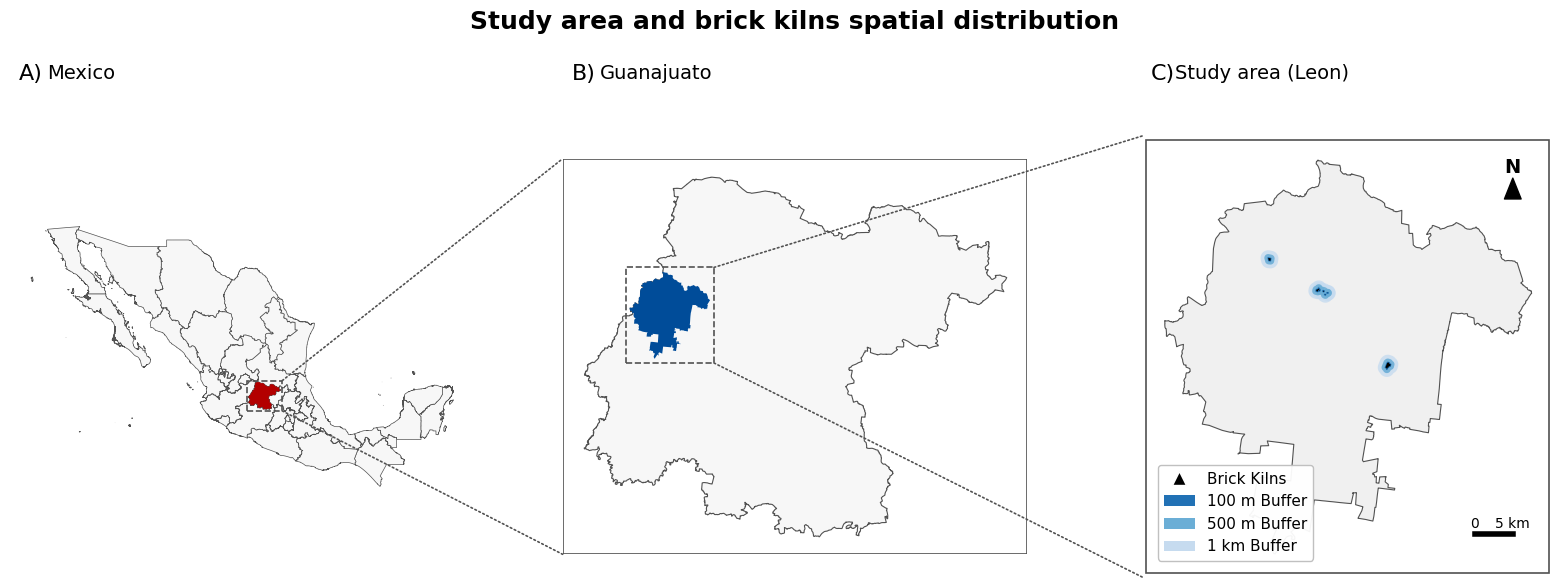

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch

# =============================================================================
# Global Configuration
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['pdf.fonttype'] = 42  # Ensure vector fonts for publication

# =============================================================================
# Data Loading & Projection
# =============================================================================
# Load administrative boundaries (WGS84)
mexico = gpd.read_file('/content/fig1/nacional/00ent.shp').to_crs(epsg=4326)
gto = gpd.read_file('/content/fig1/guanajuato/11ent.shp').to_crs(epsg=4326)
mun = gpd.read_file('/content/fig1/guanajuato/11mun.shp').to_crs(epsg=4326)

# Filter target municipality
leon = mun[mun['NOMGEO'] == 'León']

# Load study targets and project to UTM Zone 14N for accurate metric buffering
brick_kilns = gpd.read_file('/content/fig1/data/ladrilleras/ladrilleras_p.shp').to_crs(epsg=32614)

# =============================================================================
# Geoprocessing: Impact Buffers
# =============================================================================
buffer_100m = brick_kilns.buffer(100)
buffer_500m = brick_kilns.buffer(500)
buffer_1km = brick_kilns.buffer(1000)

# =============================================================================
# Plot Initialization & Styling
# =============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Title setup (positioned at the top with adequate spacing)
fig.suptitle('Study area and brick kilns spatial distribution',
             fontsize=18, fontweight='bold', y=0.97)

# Palette
colors = {
    'gto': '#b30000',
    'leon': '#004c99',
    'buffer_1km': '#c6dbef',
    'buffer_500m': '#6baed6',
    'buffer_100m': '#2171b5',
    'kilns': 'black',
    'zoom_lines': '#525252'
}

# =============================================================================
# Panel A: National Context (Mexico)
# =============================================================================
mexico.plot(ax=ax1, color='#f7f7f7', edgecolor='#525252', linewidth=0.5)
gto.plot(ax=ax1, color=colors['gto'])

# =============================================================================
# Panel B: State Context (Guanajuato)
# =============================================================================
gto.plot(ax=ax2, color='#f7f7f7', edgecolor='#525252', linewidth=0.8)
leon.plot(ax=ax2, color=colors['leon'])

# Draw bounding box for Guanajuato (5% margin)
minx_gto, miny_gto, maxx_gto, maxy_gto = gto.total_bounds
margin_x = (maxx_gto - minx_gto) * 0.05
margin_y = (maxy_gto - miny_gto) * 0.05

rect_gto = Rectangle(
    (minx_gto - margin_x, miny_gto - margin_y),
    (maxx_gto - minx_gto) + (margin_x * 2),
    (maxy_gto - miny_gto) + (margin_y * 2),
    fill=False, edgecolor=colors['zoom_lines'], linestyle='-', linewidth=1.2
)
ax2.add_patch(rect_gto)

# =============================================================================
# Panel C: Local Context (Leon & Buffers)
# =============================================================================
leon_utm = leon.to_crs(epsg=32614)
leon_utm.plot(ax=ax3, color='#f0f0f0', edgecolor='#525252', linewidth=0.8)

# Layer buffers (largest to smallest to prevent occlusion)
buffer_1km.plot(ax=ax3, color=colors['buffer_1km'], edgecolor='none', alpha=0.8)
buffer_500m.plot(ax=ax3, color=colors['buffer_500m'], edgecolor='none', alpha=0.9)
buffer_100m.plot(ax=ax3, color=colors['buffer_100m'], edgecolor='none', alpha=1.0)
brick_kilns.plot(ax=ax3, color=colors['kilns'], marker='^', markersize=15)

# Draw bounding box for Leon (5% margin)
bx = leon_utm.total_bounds
margin_xl = (bx[2] - bx[0]) * 0.05
margin_yl = (bx[3] - bx[1]) * 0.05

rect_leon = Rectangle(
    (bx[0] - margin_xl, bx[1] - margin_yl),
    (bx[2] - bx[0]) + (margin_xl * 2),
    (bx[3] - bx[1]) + (margin_yl * 2),
    fill=False, edgecolor=colors['zoom_lines'], linestyle='-', linewidth=1.2
)
ax3.add_patch(rect_leon)

# Apply 6% margin to plot limits to avoid cropping the bounding box
mx = (bx[2] - bx[0]) * 0.06
my = (bx[3] - bx[1]) * 0.06
ax3.set_xlim(bx[0] - mx, bx[2] + mx)
ax3.set_ylim(bx[1] - my, bx[3] + my)

# =============================================================================
# Cartographic Elements (Panel C)
# =============================================================================
# North Arrow
nx = bx[2] - margin_xl
ny = bx[3] - margin_yl
ax3.text(nx, ny + (my * 0.1), 'N', fontsize=14, fontweight='bold', ha='center', va='bottom')
ax3.annotate('', xy=(nx, ny + (my * 0.05)), xytext=(nx, ny - (my * 0.4)),
             arrowprops=dict(facecolor='black', edgecolor='black', width=4, headwidth=12, headlength=15))

# Scale Bar (5 km)
scale_len = 5000
start_x = bx[2] - margin_xl - scale_len
start_y = bx[1] + (my * 0.8)

ax3.plot([start_x, start_x + scale_len], [start_y, start_y], color='black', linewidth=4, zorder=10)
ax3.text(start_x, start_y + (my * 0.15), '0', ha='center', va='bottom', fontsize=10)
ax3.text(start_x + scale_len, start_y + (my * 0.15), '5 km', ha='center', va='bottom', fontsize=10)

# =============================================================================
# Zoom Projection Lines Helper
# =============================================================================
def draw_zoom_effect(ax_source, ax_target, target_gdf, line_color, margin=0.05):
    """Draws a bounding box on the source axis and connects it to the target axis."""
    minx, miny, maxx, maxy = target_gdf.total_bounds

    # Calculate and apply margin
    mx = (maxx - minx) * margin
    my = (maxy - miny) * margin
    minx -= mx; miny -= my; maxx += mx; maxy += my

    # Source bounding box
    rect = Rectangle((minx, miny), maxx - minx, maxy - miny,
                     fill=False, edgecolor=line_color, linestyle='--', linewidth=1.2)
    ax_source.add_patch(rect)

    # Connecting lines (Top and Bottom)
    conn_top = ConnectionPatch(xyA=(maxx, maxy), xyB=(0, 1), coordsA="data", coordsB="axes fraction",
                              axesA=ax_source, axesB=ax_target, color=line_color, linestyle=':', linewidth=1.2)
    conn_bot = ConnectionPatch(xyA=(maxx, miny), xyB=(0, 0), coordsA="data", coordsB="axes fraction",
                              axesA=ax_source, axesB=ax_target, color=line_color, linestyle=':', linewidth=1.2)

    ax_source.add_artist(conn_top)
    ax_source.add_artist(conn_bot)

# Apply projections
draw_zoom_effect(ax1, ax2, gto, colors['zoom_lines'])
draw_zoom_effect(ax2, ax3, leon, colors['zoom_lines'])

# =============================================================================
# Final Layout Adjustments
# =============================================================================
for ax in [ax1, ax2, ax3]:
    ax.axis('off')

# Reserve top space for title and labels
plt.tight_layout(rect=[0, 0, 1, 0.85])

# Panel Labels
letters = ['A)', 'B)', 'C)']
titles = ['Mexico', 'Guanajuato', 'Study area (Leon)']

for i, ax in enumerate([ax1, ax2, ax3]):
    trans = mtransforms.blended_transform_factory(ax.transAxes, fig.transFigure)
    ax.text(0.02, 0.88, letters[i], transform=trans,
            fontsize=16, va='top', ha='left')
    ax.text(0.08, 0.88, titles[i], transform=trans,
            fontsize=14, va='top', ha='left')

# Legend
legend_elements = [
    Line2D([0], [0], marker='^', color='w', label='Brick Kilns', markerfacecolor=colors['kilns'], markersize=10),
    Patch(facecolor=colors['buffer_100m'], edgecolor='none', label='100 m Buffer'),
    Patch(facecolor=colors['buffer_500m'], edgecolor='none', label='500 m Buffer'),
    Patch(facecolor=colors['buffer_1km'], edgecolor='none', label='1 km Buffer')
]

ax3.legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(0.02, 0.02),
           frameon=True, facecolor='white', framealpha=0.95, edgecolor='#bdbdbd', fontsize=11)

# =============================================================================
# Export
# =============================================================================
plt.savefig("fig1_study_area.pdf", dpi=600, bbox_inches='tight')
plt.show()

# Plot designed by Singularity Research Collective (SRC)
# https://github.com/Singularity-MX
# https://instagram.com/singularity.open

In [ ]:
# Draw.io

## Boxplots Wilcoxon

 RESULTADOS PRUEBA DE WILCOXON (PAREADA) POR AÑO Y VARIABLE

--- Variable: LST_Celsius ---
Año 2024 | p-value: 0.00781 | **
Año 2025 | p-value: 0.00781 | **
Año 2026 | p-value: 0.00781 | **

--- Variable: NDMI ---
Año 2024 | p-value: 0.00781 | **
Año 2025 | p-value: 0.00781 | **
Año 2026 | p-value: 0.00781 | **

--- Variable: NDSI ---
Año 2024 | p-value: 0.00781 | **
Año 2025 | p-value: 0.02344 | *
Año 2026 | p-value: 0.00781 | **

--- Variable: IBI ---
Año 2024 | p-value: 0.00781 | **
Año 2025 | p-value: 0.00781 | **
Año 2026 | p-value: 0.00781 | **

--- Variable: NDVI ---
Año 2024 | p-value: 0.07812 | n.s.
Año 2025 | p-value: 0.01562 | *
Año 2026 | p-value: 0.19531 | n.s.

--- Variable: UI ---
Año 2024 | p-value: 0.00781 | **
Año 2025 | p-value: 0.00781 | **
Año 2026 | p-value: 0.10938 | n.s.


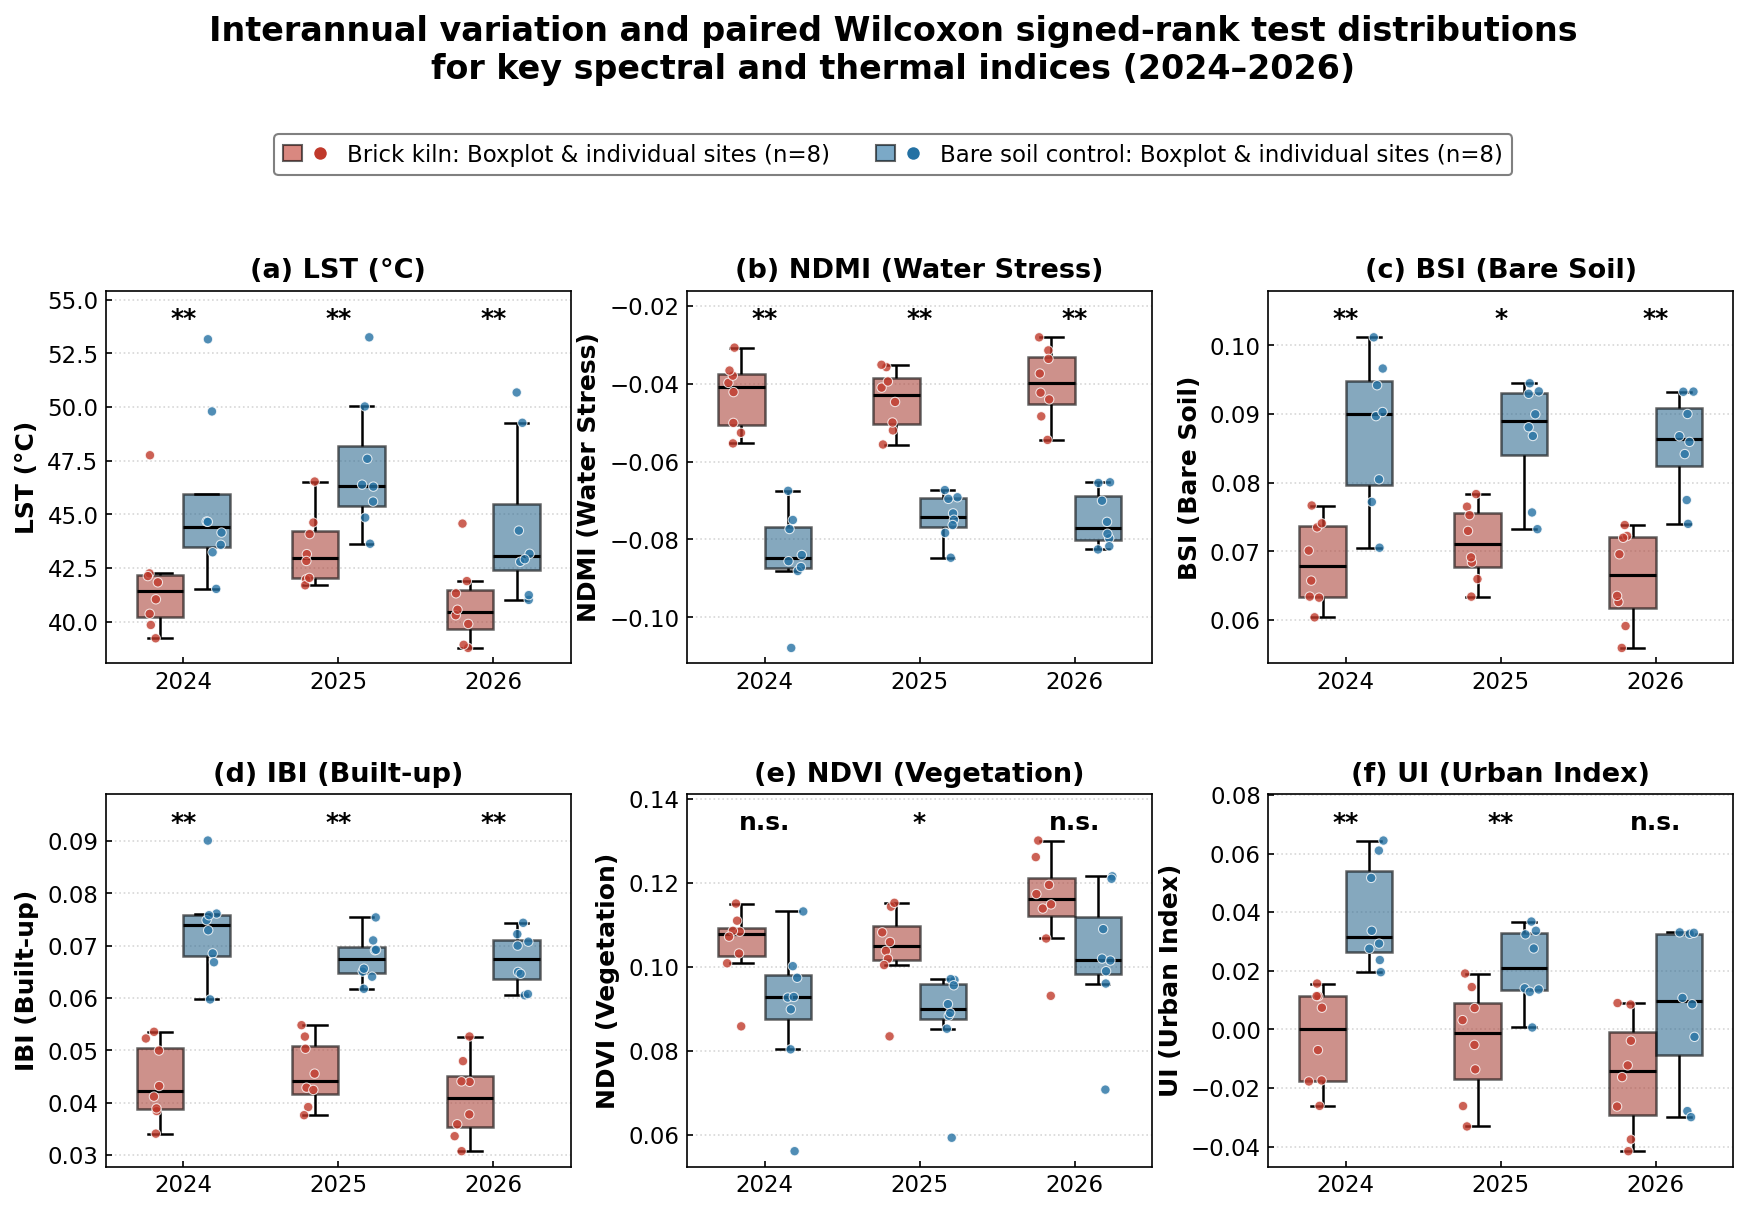

✅ Fig. 3 guardada
/content/resultados_paper/Fig3_Boxplots_Wilcoxon.png
/content/resultados_paper/Fig3_Boxplots_Wilcoxon.pdf

Figure caption: Significance levels (Wilcoxon signed-rank test): *** p < 0.001, ** p < 0.01, * p < 0.05, n.s. not significant. Boxplots show the median and interquartile range (IQR), with the values of the 8 paired geographic polygons displayed as individual points.


In [ ]:
# ==============================================================================
# Boxplots Wilcoxon por variable y año (Diseño Pareado)
# Archivos necesarios: paired_table_2024.csv, paired_table_2025.csv, paired_table_2026.csv
# Target Journal: Atmósfera (UNAM) — 300 dpi
# ==============================================================================

import pandas as pd
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings

warnings.filterwarnings('ignore')

OUT_DIR = '/content/paper_results'
os.makedirs(OUT_DIR, exist_ok=True)

# ==============================================================================
# FONT CONFIGURATION
# ==============================================================================
FONT_TITLE = 16
FONT_PANEL = 13
FONT_AXIS = 12
FONT_TICKS = 11
FONT_LEGEND = 11
FONT_SIG = 12

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': FONT_TICKS,
    'axes.labelsize': FONT_AXIS,
    'axes.titlesize': FONT_PANEL,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'xtick.labelsize': FONT_TICKS,
    'ytick.labelsize': FONT_TICKS,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

# ==============================================================================
# 1. LOAD PAIRED DATA
# ==============================================================================
years = [2024, 2025, 2026]
dfs = []

for year in years:
    path = f'/content/paired_table_{year}.csv'
    if os.path.exists(path):
        dfs.append(pd.read_csv(path))
    else:
        print(f"Warning: {path} not found")

df = pd.concat(dfs, ignore_index=True)

for col in ['.geo', 'system:index']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

rename_columns = {
    'LST_Celsius_mean': 'LST_Celsius',
    'NDMI_mean': 'NDMI',
    'NDSI_mean': 'NDSI',
    'IBI_mean': 'IBI',
    'NDVI_mean': 'NDVI',
    'UI_mean': 'UI'
}
df.rename(columns=rename_columns, inplace=True)

df['class'] = df['class'].astype(str)
df['year'] = df['year'].astype(int)

# ==============================================================================
# 2. VARIABLE CONFIGURATION
# ==============================================================================
VARS_PLOT = ['LST_Celsius', 'NDMI', 'NDSI', 'IBI', 'NDVI', 'UI']

LABELS = {
    'LST_Celsius': 'LST (°C)',
    'NDMI': 'NDMI (Water Stress)',
    'NDSI': 'BSI (Bare Soil)',
    'IBI': 'IBI (Built-up)',
    'NDVI': 'NDVI (Vegetation)',
    'UI': 'UI (Urban Index)'
}

COLORS = {
    'kiln': '#c0392b',
    'bare_soil': '#2471a3'
}

# ==============================================================================
# 3. FIGURE CREATION
# ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.subplots_adjust(hspace=0.35, wspace=0.25, top=0.84)
axes = axes.flatten()
letters = ['a', 'b', 'c', 'd', 'e', 'f']

print("="*80)
print(" PAIRED WILCOXON TEST RESULTS BY YEAR AND VARIABLE")
print("="*80)

# ==============================================================================
# 4. BOXPLOTS + WILCOXON
# ==============================================================================
for idx, var in enumerate(VARS_PLOT):
    ax = axes[idx]

    sns.boxplot(
        data=df, x='year', y=var, hue='class', palette=COLORS, ax=ax,
        width=0.6, showfliers=False,
        boxprops=dict(alpha=0.6, edgecolor='black', linewidth=1.2),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2)
    )

    sns.stripplot(
        data=df, x='year', y=var, hue='class', palette=COLORS, ax=ax,
        dodge=True, edgecolor='white', linewidth=0.5, alpha=0.8, size=4.5
    )

    if ax.get_legend():
        ax.get_legend().remove()

    y_max, y_min = df[var].max(), df[var].min()
    range_val = y_max - y_min

    print(f"\n--- Variable: {var} ---")

    for i, year in enumerate(years):
        sub_kiln = df[(df['year'] == year) & (df['class'] == 'kiln')].sort_values('pair_id')[var].values
        sub_ctrl = df[(df['year'] == year) & (df['class'] == 'bare_soil')].sort_values('pair_id')[var].values

        if len(sub_kiln) == len(sub_ctrl) and len(sub_kiln) > 3:
            stat, p = stats.wilcoxon(sub_kiln, sub_ctrl)
            if p < 0.001: sig = '***'
            elif p < 0.01: sig = '**'
            elif p < 0.05: sig = '*'
            else: sig = 'n.s.'

            print(f"Year {year} | p-value: {p:.5f} | {sig}")

            ax.text(i, y_max + range_val * 0.02, sig, ha='center', va='bottom', fontsize=FONT_SIG, fontweight='bold')

    ax.set_title(f'({letters[idx]}) {LABELS[var]}', fontsize=FONT_PANEL, fontweight='bold')
    ax.set_xlabel('', fontsize=FONT_AXIS)
    ax.set_ylabel(LABELS[var], fontsize=FONT_AXIS, fontweight='bold')
    ax.tick_params(direction='in', length=3, labelsize=FONT_TICKS)
    ax.set_ylim(y_min - range_val * 0.05, y_max + range_val * 0.15)
    ax.grid(True, linestyle=':', alpha=0.5, axis='y')

# ==============================================================================
# 5. GLOBAL LEGEND
# ==============================================================================
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

box_kiln = mpatches.Patch(facecolor=COLORS['kiln'], edgecolor='black', alpha=0.6)
box_ctrl = mpatches.Patch(facecolor=COLORS['bare_soil'], edgecolor='black', alpha=0.6)
dot_kiln = mlines.Line2D([], [], color='none', marker='o', markerfacecolor=COLORS['kiln'], markeredgecolor='white', markersize=7)
dot_ctrl = mlines.Line2D([], [], color='none', marker='o', markerfacecolor=COLORS['bare_soil'], markeredgecolor='white', markersize=7)

fig.legend(
    handles=[(box_kiln, dot_kiln), (box_ctrl, dot_ctrl)],
    labels=['Brick kiln: Boxplot & individual sites (n=8)', 'Bare soil control: Boxplot & individual sites (n=8)'],
    loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2, fontsize=FONT_LEGEND,
    framealpha=1, edgecolor='gray',
    handler_map={tuple: matplotlib.legend_handler.HandlerTuple(ndivide=None)}
)

# ==============================================================================
# 6. OVERALL TITLE
# ==============================================================================
fig.suptitle(
    'Interannual variation and paired Wilcoxon signed-rank test distributions\n'
    'for key spectral and thermal indices (2024–2026)',
    fontsize=FONT_TITLE, fontweight='bold', y=1.07
)

# ==============================================================================
# 7. SAVE
# ==============================================================================
plt.savefig(f'{OUT_DIR}/Boxplots_Wilcoxon.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUT_DIR}/Boxplots_Wilcoxon.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("="*80)
print("Plot saved successfully")
print(f"{OUT_DIR}/Boxplots_Wilcoxon.png")
print(f"{OUT_DIR}/Boxplots_Wilcoxon.pdf")
print("="*80)
print(
    "\nFigure caption: Significance levels (Wilcoxon signed-rank test): "
    "*** p < 0.001, ** p < 0.01, * p < 0.05, n.s. not significant. "
    "Boxplots show the median and interquartile range (IQR), with the values "
    "of the 8 paired geographic polygons displayed as individual points."
)

## Heatmap Δ(brick kiln − bare soil control) by polygon pair and variable

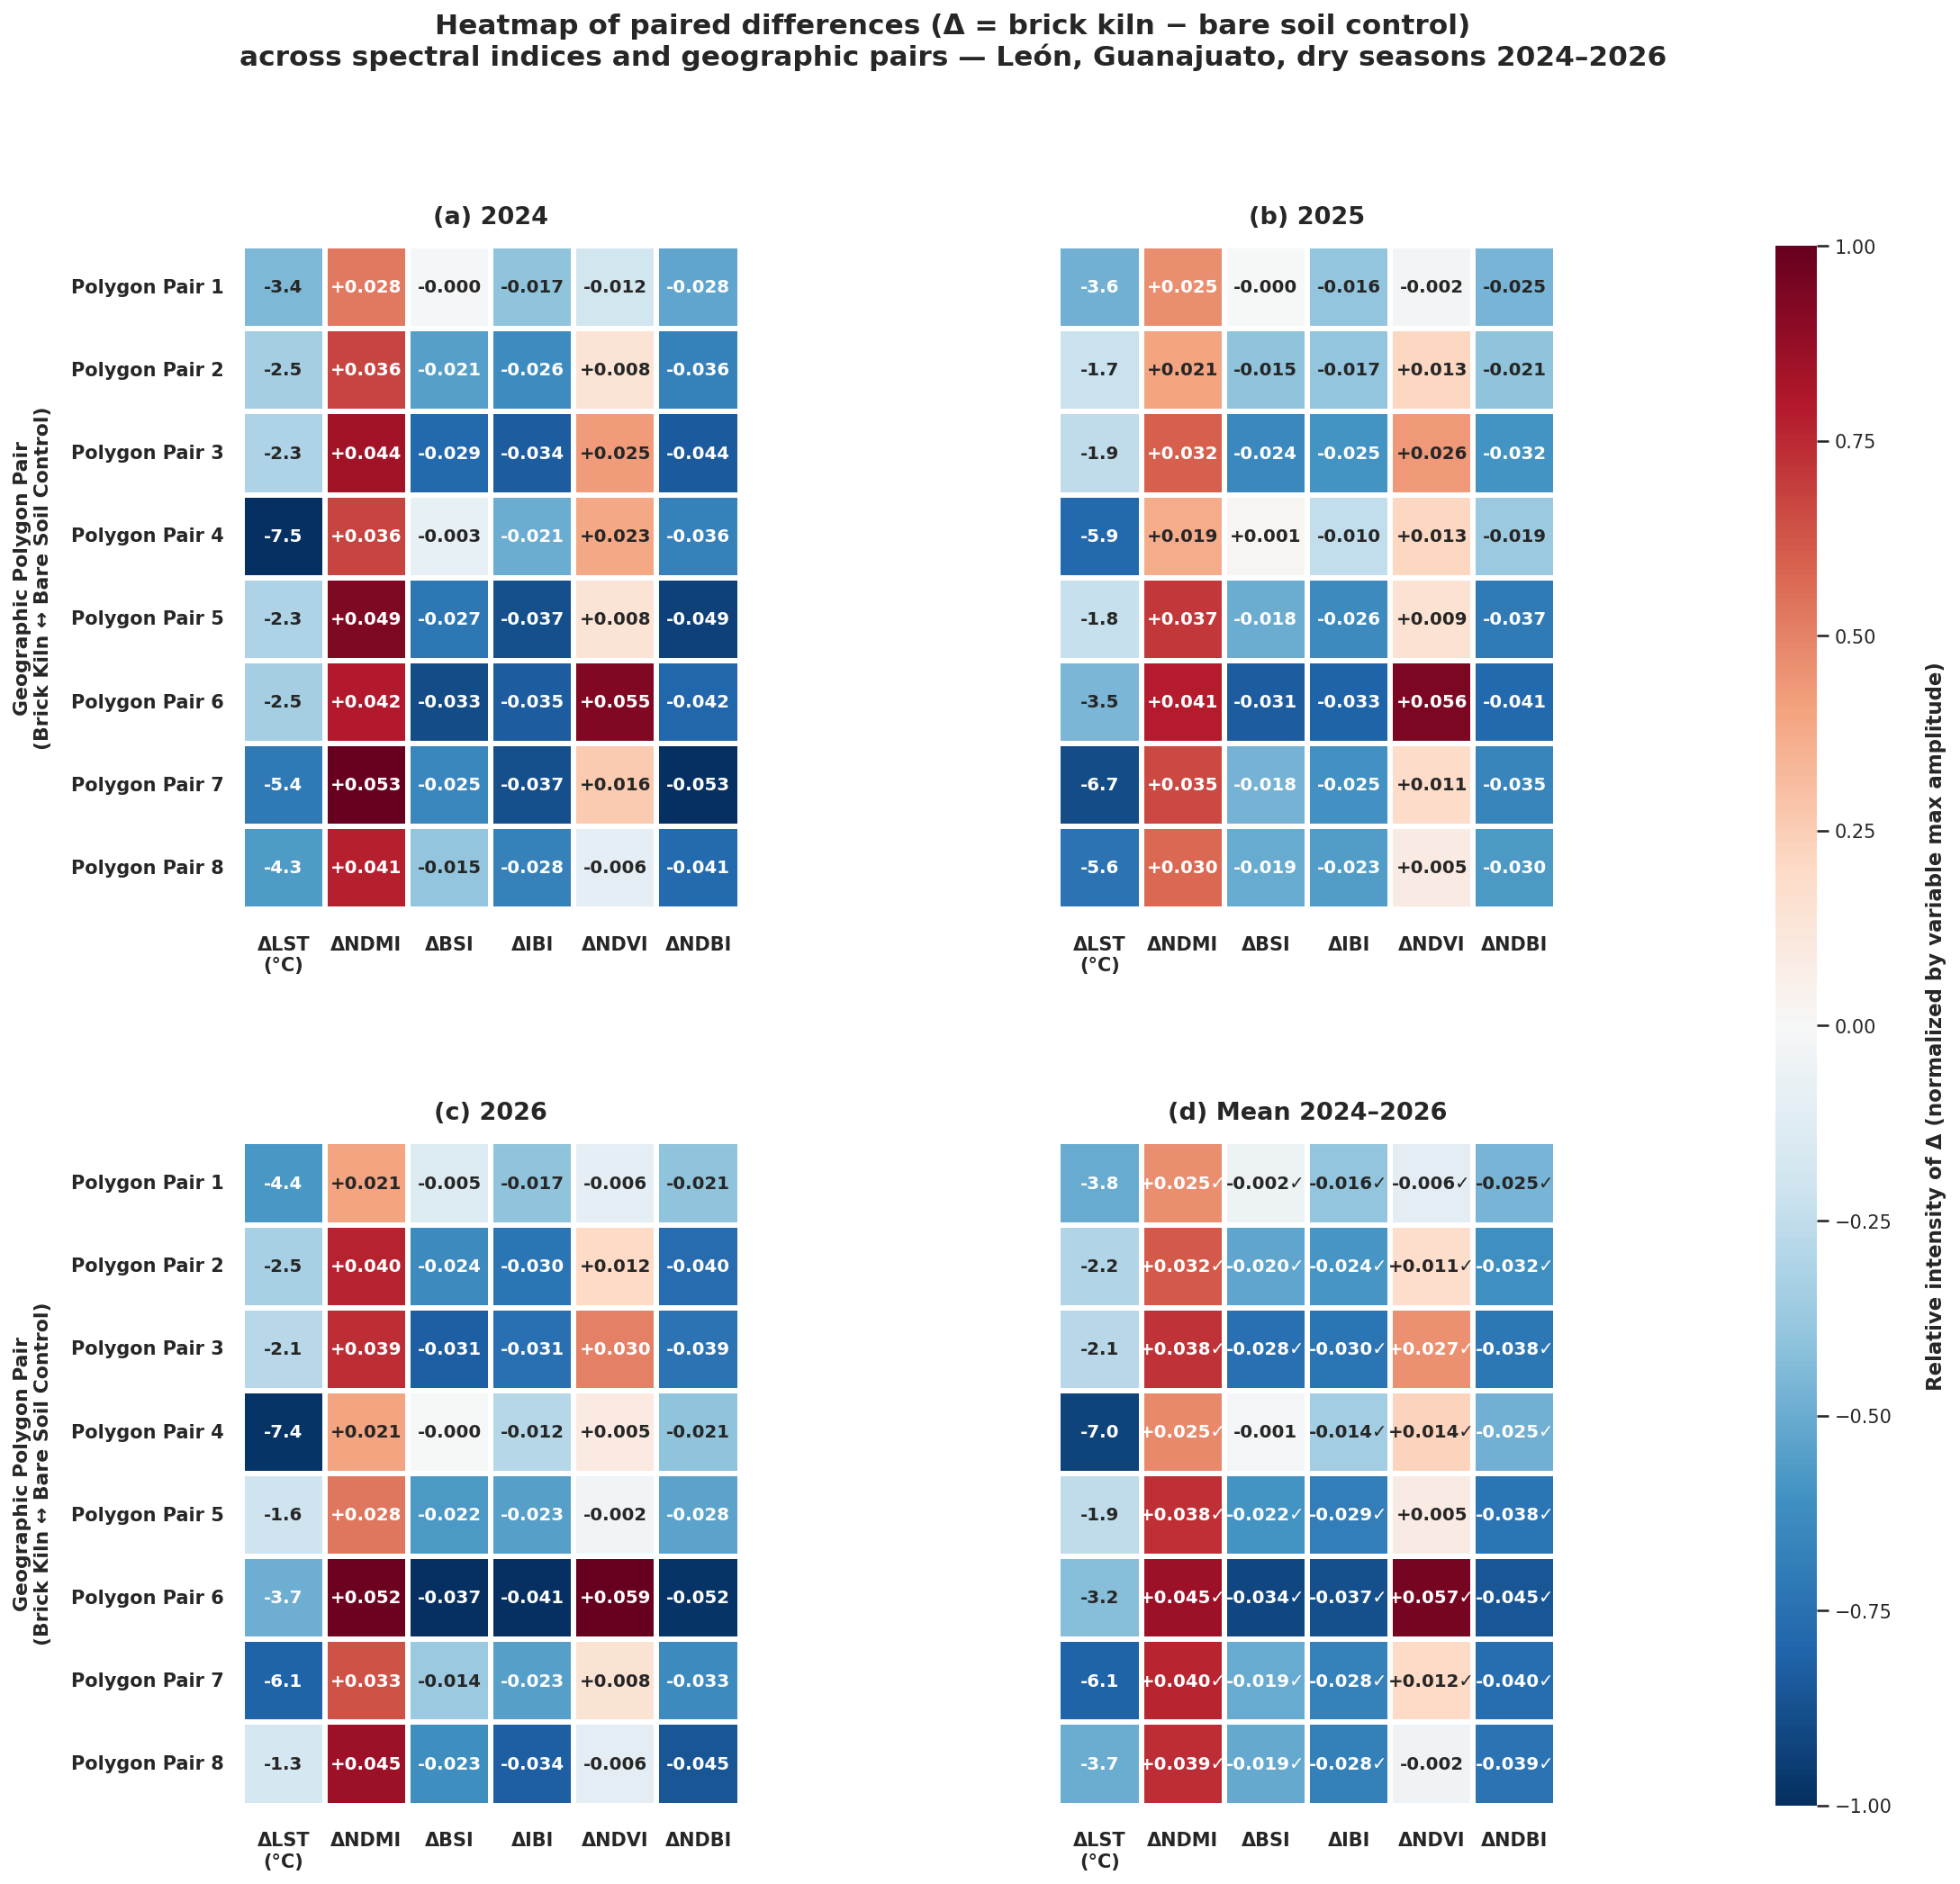

 NUMERICAL RESULTS FOR ANALYSIS (COPY AND PASTE THIS INTO CHAT) 

--- Differences (Δ = Brick Kiln - Control) Year 2024 ---
        LST_Celsius   NDMI    BSI    IBI   NDVI   NDBI
par_id                                                
1.0          -3.388  0.028 -0.000 -0.017 -0.012 -0.028
2.0          -2.540  0.036 -0.021 -0.026  0.008 -0.036
3.0          -2.302  0.044 -0.029 -0.034  0.025 -0.044
4.0          -7.546  0.036 -0.003 -0.021  0.023 -0.036
5.0          -2.319  0.049 -0.027 -0.037  0.008 -0.049
6.0          -2.544  0.042 -0.033 -0.035  0.055 -0.042
7.0          -5.405  0.053 -0.025 -0.037  0.016 -0.053
8.0          -4.285  0.041 -0.015 -0.028 -0.006 -0.041

--- Differences (Δ = Brick Kiln - Control) Year 2025 ---
        LST_Celsius   NDMI    BSI    IBI   NDVI   NDBI
par_id                                                
1.0          -3.627  0.025 -0.000 -0.016 -0.002 -0.025
2.0          -1.701  0.021 -0.015 -0.017  0.013 -0.021
3.0          -1.937  0.032 -0.024 -0.025  0.026 -

In [ ]:
# ==============================================================================
# Heatmap Δ(brick kiln − bare soil control) by polygon pair and variable
# Journal: Atmósfera (UNAM) — 300 dpi, Seaborn corrected + Data Print + PDF
# Layout: 2x2 grid with a single shared vertical colorbar
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

OUT_DIR = '/content/paper_results'
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------------------------
# 1. LOAD AND CLEAN DATA
# ------------------------------------------------------------------------------
dfs = []
for year in [2024, 2025, 2026]:
    path = f'/content/paired_table_{year}.csv'
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['year'] = year
        dfs.append(df)

df_pairs = pd.concat(dfs, ignore_index=True)

# Rename NDSI to BSI
df_pairs.rename(columns={'NDSI': 'BSI', 'NDSI_mean': 'BSI'}, inplace=True, errors='ignore')

VARS_HIP = ['LST_Celsius', 'NDMI', 'BSI', 'IBI', 'NDVI', 'NDBI']

for v in VARS_HIP:
    if f'{v}_mean' in df_pairs.columns:
        df_pairs.rename(columns={f'{v}_mean': v}, inplace=True)

# ------------------------------------------------------------------------------
# 2. CALCULATE PAIRED DIFFERENCES (Δ)
# ------------------------------------------------------------------------------
diffs_by_year = {}
for year in [2024, 2025, 2026]:
    sub = df_pairs[df_pairs['year'] == year]
    kilns = sub[sub['class'] == 'kiln'].set_index('pair_id')
    ctrls = sub[sub['class'] == 'bare_soil'].set_index('pair_id')

    pairs = kilns.index.intersection(ctrls.index)
    diffs_by_year[year] = kilns.loc[pairs, VARS_HIP] - ctrls.loc[pairs, VARS_HIP]

diff_mean = pd.concat(diffs_by_year).groupby('pair_id').mean()

max_abs_var = {var: 0 for var in VARS_HIP}
for df in list(diffs_by_year.values()) + [diff_mean]:
    for var in VARS_HIP:
        max_abs_var[var] = max(max_abs_var[var], df[var].abs().max())

# ------------------------------------------------------------------------------
# 3. FIGURE GENERATION — 2x2 GRID + SHARED VERTICAL COLORBAR
# ------------------------------------------------------------------------------
sns.set_theme(style="white", font="DejaVu Sans")

fig = plt.figure(figsize=(16, 15))
gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[1, 1, 0.06],
    height_ratios=[1, 1],
    wspace=0.25,
    hspace=0.35,
    figure=fig
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
cax = fig.add_subplot(gs[:, 2])

axes_grid = [ax_a, ax_b, ax_c, ax_d]
titles = ['(a) 2024', '(b) 2025', '(c) 2026', '(d) Mean 2024–2026']
x_labels = ['ΔLST\n(°C)', 'ΔNDMI', 'ΔBSI', 'ΔIBI', 'ΔNDVI', 'ΔNDBI']
data_panels = [diffs_by_year[2024], diffs_by_year[2025], diffs_by_year[2026], diff_mean]

LEFT_COL_IDX = {0, 2}

for idx, (ax, title, df_plot) in enumerate(zip(axes_grid, titles, data_panels)):

    annot_text = df_plot.copy()
    for col in df_plot.columns:
        if col == 'LST_Celsius':
            annot_text[col] = df_plot[col].apply(lambda x: f"{x:+.1f}")
        else:
            annot_text[col] = df_plot[col].apply(lambda x: f"{x:+.3f}")

        if idx == 3 and col != 'LST_Celsius':
            for pair in df_plot.index:
                vals = [diffs_by_year[y].loc[pair, col] for y in [2024, 2025, 2026]]
                signs = [np.sign(v) for v in vals if not np.isnan(v)]
                if len(set(signs)) == 1 and len(signs) == 3:
                    annot_text.loc[pair, col] += "✓"

    color_data = df_plot.copy()
    for col in color_data.columns:
        if max_abs_var[col] != 0:
            color_data[col] = color_data[col] / max_abs_var[col]

    heatmap = sns.heatmap(
        color_data, annot=annot_text, fmt="", cmap="RdBu_r", vmin=-1, vmax=1,
        cbar=(idx == 3), cbar_ax=cax if idx == 3 else None, square=True, ax=ax,
        linewidths=2, linecolor='white', annot_kws={"size": 9.5, "weight": "bold"}
    )

    if idx == 3:
        cbar = heatmap.collections[0].colorbar
        cbar.set_label('Relative intensity of Δ (normalized by variable max amplitude)',
                        labelpad=18, fontsize=11, fontweight='bold')
        cbar.ax.tick_params(labelsize=10)

    ax.set_title(title, fontweight='bold', pad=12, fontsize=13)
    ax.set_xticklabels(x_labels, rotation=0, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', pad=8)

    if idx in LEFT_COL_IDX:
        ax.set_ylabel("Geographic Polygon Pair\n(Brick Kiln ↔ Bare Soil Control)",
                       fontsize=10.5, labelpad=10, fontweight='bold')
        ax.set_yticklabels([f"Polygon Pair {int(i)}" for i in df_plot.index],
                            rotation=0, fontsize=10, fontweight='bold')
    else:
        ax.set_ylabel("")
        ax.set_yticks([])

# ------------------------------------------------------------------------------
# 4. TITLES AND EXPORT
# ------------------------------------------------------------------------------
fig.suptitle(
    'Heatmap of paired differences (Δ = brick kiln − bare soil control)\n'
    'across spectral indices and geographic pairs — León, Guanajuato, dry seasons 2024–2026',
    fontsize=15, fontweight='bold', y=0.995
)

plt.savefig(f'{OUT_DIR}/Heatmap_2x2.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUT_DIR}/Heatmap_2x2.pdf', bbox_inches='tight', facecolor='white')

plt.show()
plt.close()

# ------------------------------------------------------------------------------
# 5. PRINT DATA FOR ANALYSIS
# ------------------------------------------------------------------------------
print("="*80)
print(" NUMERICAL RESULTS FOR ANALYSIS (COPY AND PASTE THIS INTO CHAT) ")
print("="*80)

for year in [2024, 2025, 2026]:
    print(f"\n--- Differences (Δ = Brick Kiln - Control) Year {year} ---")
    print(diffs_by_year[year].round(3).to_string())

print("\n--- Average Differences (Mean 2024-2026) ---")
print(diff_mean.round(3).to_string())
print("\n" + "="*80)
print("Plot successfully restructured as 2x2 grid, displayed, and saved as PNG & PDF.")

## Spatial Gradient 100 → 500 → 1000 m

Píxeles totales: 327,012
Clases: ['ladrillera' 'suelo_desnudo']
Buffers (m): [np.int64(100), np.int64(500), np.int64(1000)]
Años: [np.int64(2024), np.int64(2025), np.int64(2026)]

--- Spearman rho: gradiente por clase (Úsalo para tu tabla en LaTeX) ---
        clase    variable       rho            p sig
   ladrillera LST_Celsius -0.040476 1.390920e-57 ***
   ladrillera        NDMI  0.006890 6.495024e-03  **
   ladrillera        NDSI -0.008161 1.266068e-03  **
   ladrillera         IBI -0.007402 3.458283e-03  **
   ladrillera        NDVI  0.007967 1.650410e-03  **
   ladrillera        NDBI -0.006890 6.495024e-03  **
suelo_desnudo LST_Celsius -0.114230 0.000000e+00 ***
suelo_desnudo        NDMI  0.117409 0.000000e+00 ***
suelo_desnudo        NDSI -0.114585 0.000000e+00 ***
suelo_desnudo         IBI -0.121345 0.000000e+00 ***
suelo_desnudo        NDVI  0.016672 5.413334e-12 ***
suelo_desnudo        NDBI -0.117409 0.000000e+00 ***


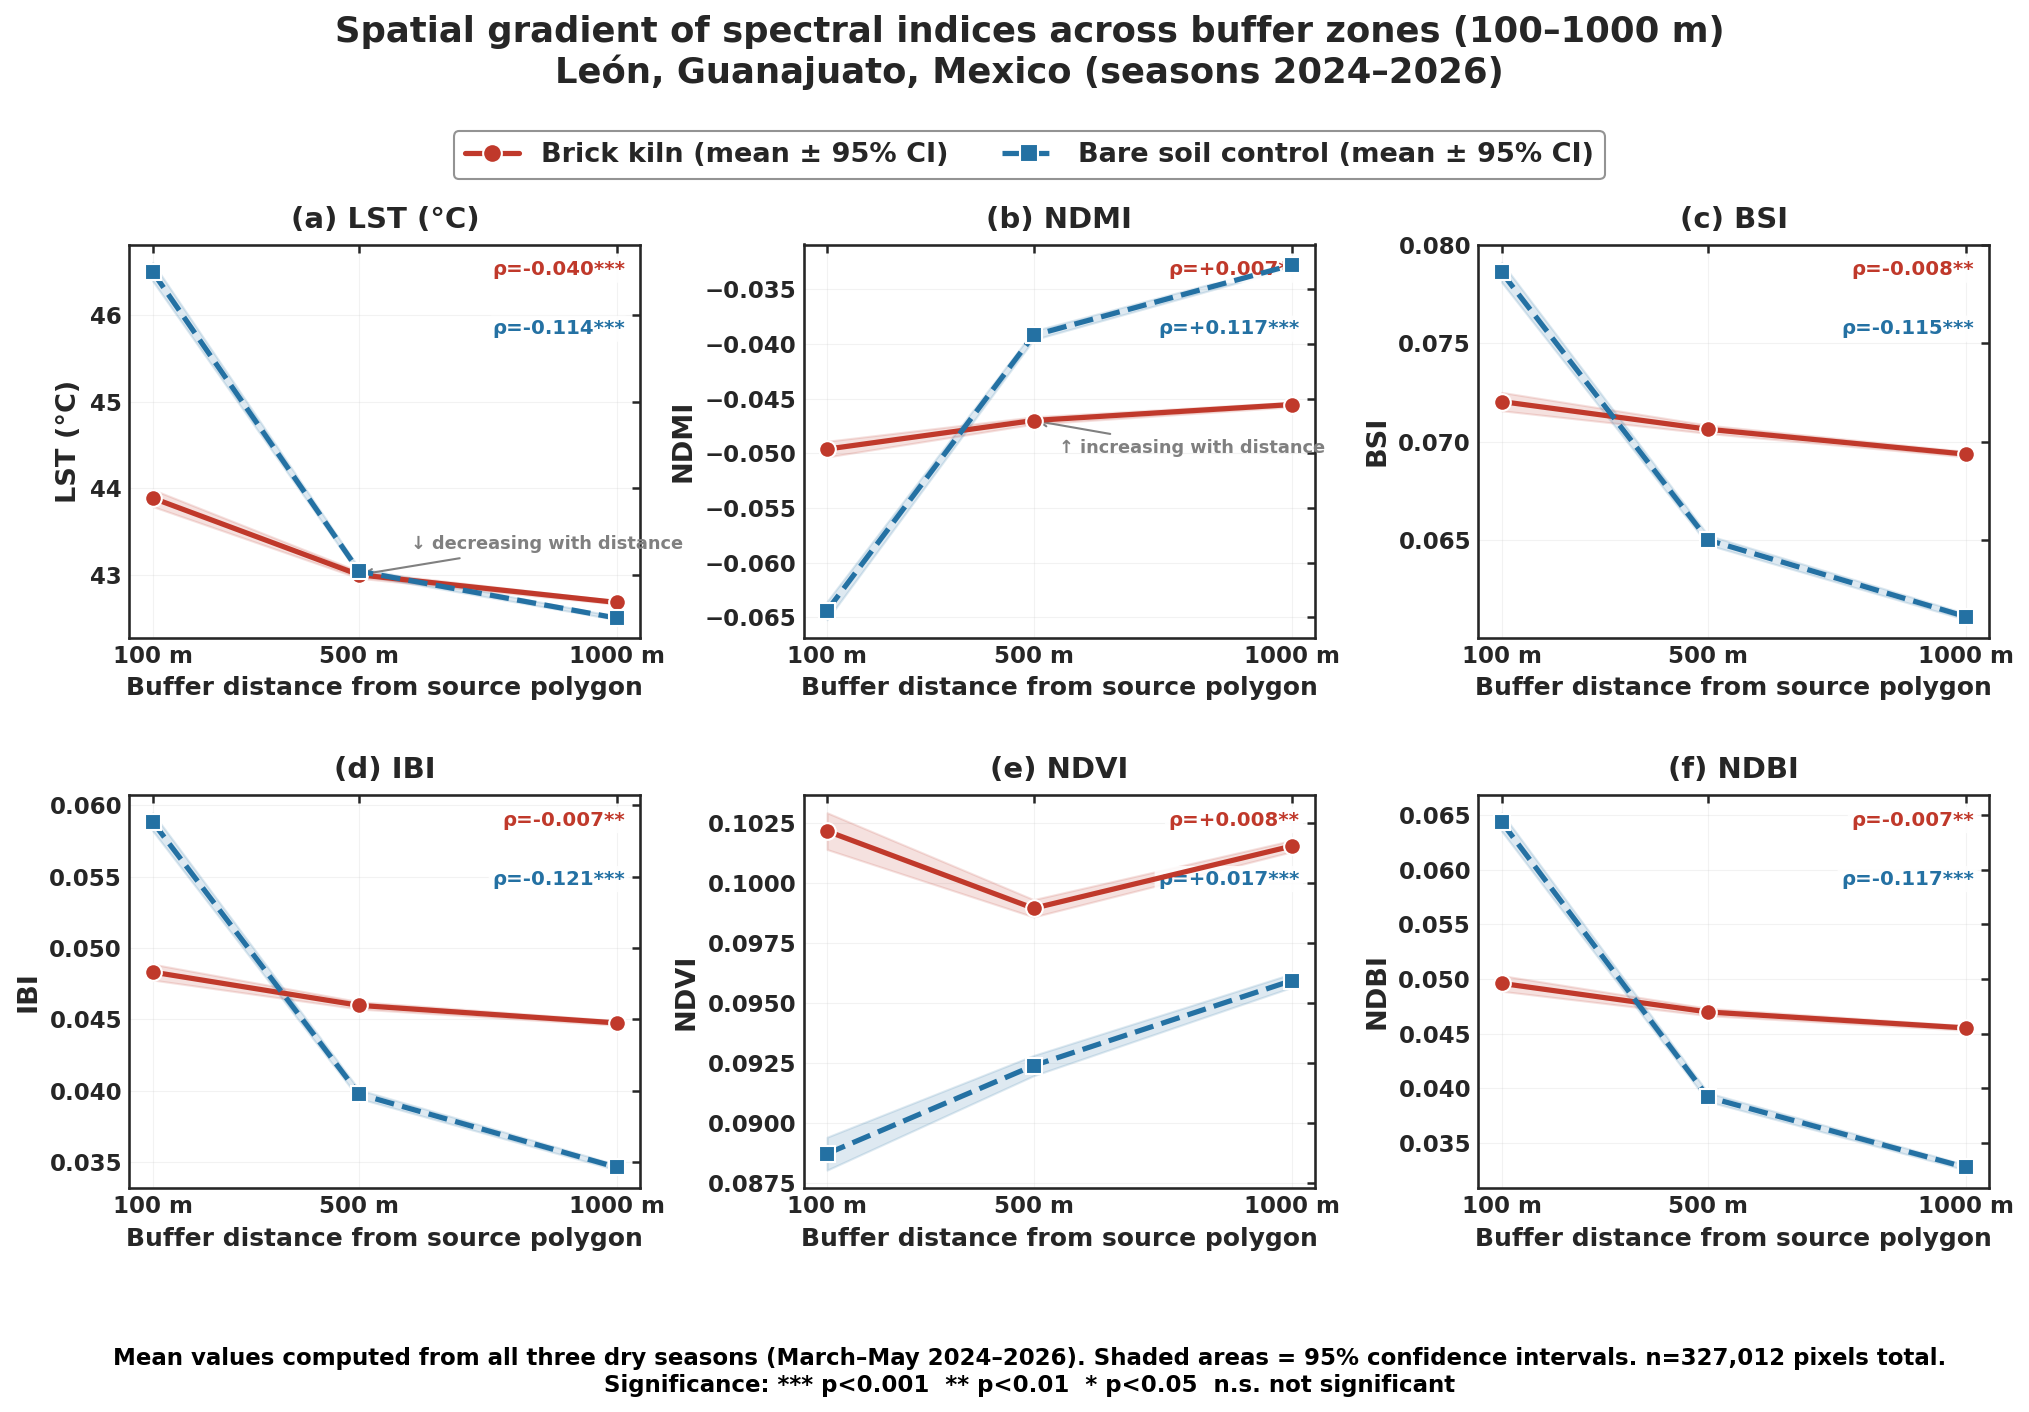


✅ Figura guardada (fuentes grandes + negritas):
   /content/resultados_paper/Fig5_Gradiente_Espacial.png  (300 dpi)
   /content/resultados_paper/Fig5_Gradiente_Espacial.pdf  (vectorial)


In [ ]:
# ==============================================================================
# Spatial Gradient 100 → 500 → 1000 m
# Required files: pixel_data_2024/25/26.csv
# Target Journal: Atmósfera (UNAM) — 300 dpi, publication size
# VERSION: larger fonts + bold text
# ==============================================================================
# Structure:
#   Main panel (2x3): mean ± 95% CI of LST, NDMI, BSI, IBI, NDVI, NDBI
#   by buffer distance (100/500/1000m) and class
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

OUT_DIR = '/content/paper_results'
os.makedirs(OUT_DIR, exist_ok=True)

# ==============================================================================
# 1. LOAD DATA
# ==============================================================================
df = pd.concat([
    pd.read_csv('/content/pixel_data_2024.csv'),
    pd.read_csv('/content/pixel_data_2025.csv'),
    pd.read_csv('/content/pixel_data_2026.csv'),
], ignore_index=True)

for col in ['.geo', 'system:index']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

VARS_PLOT = ['LST_Celsius', 'NDMI', 'NDSI', 'IBI', 'NDVI', 'NDBI']
LABELS = {
    'LST_Celsius': 'LST (°C)',
    'NDMI':        'NDMI',
    'NDSI':        'BSI',
    'IBI':         'IBI',
    'NDVI':        'NDVI',
    'NDBI':        'NDBI',
}
UNITS = {
    'LST_Celsius': '°C',
    'NDMI': 'index', 'NDSI': 'index',
    'IBI': 'index',  'NDVI': 'index', 'NDBI': 'index',
}

df = df.dropna(subset=VARS_PLOT + ['class', 'buffer_m', 'year'])
df['class']    = df['class'].astype(str)
df['buffer_m'] = df['buffer_m'].astype(int)
df['year']     = df['year'].astype(int)

CLASSES      = ['kiln', 'bare_soil']
COLORS       = {'kiln': '#c0392b', 'bare_soil': '#2471a3'}
CLASS_LABELS = {'kiln': 'Brick kiln', 'bare_soil': 'Bare soil control'}
MARKERS      = {'kiln': 'o', 'bare_soil': 's'}
BUFFERS      = [100, 500, 1000]

print(f"Total pixels: {len(df):,}")
print(f"Classes: {df['class'].unique()}")
print(f"Buffers (m): {sorted(df['buffer_m'].unique())}")
print(f"Years: {sorted(df['year'].unique())}")

# ==============================================================================
# 2. CALCULATE STATISTICS: mean, 95% CI, Spearman rho by variable and class
# ==============================================================================
def ci95(series):
    """95% Confidence Interval based on t-distribution."""
    n = len(series)
    if n < 2:
        return 0
    se = series.std() / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n-1)
    return t_crit * se

# Statistics by class × buffer (average of all 3 years)
stats_grad = (
    df.groupby(['class', 'buffer_m'])[VARS_PLOT]
    .agg(['mean', ci95])
    .reset_index()
)

# Spearman rho by class × variable (across all years and buffers)
rho_table = []
for cls in CLASSES:
    for var in VARS_PLOT:
        sub = df[df['class'] == cls][['buffer_m', var]].dropna()
        if len(sub) > 10:
            rho, p = stats.spearmanr(sub['buffer_m'], sub[var])
            rho_table.append({
                'class': cls, 'variable': var,
                'rho': rho, 'p': p,
                'sig': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
            })
df_rho = pd.DataFrame(rho_table)

print("\n--- Spearman rho: spatial gradient by class ---")
print(df_rho.to_string(index=False))

# ==============================================================================
# 3. MAIN FIGURE (2x3 Horizontal) — LARGE BOLD FONTS
# ==============================================================================
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.weight':       'bold',
    'font.size':         12,
    'axes.labelsize':    13,
    'axes.labelweight':  'bold',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'xtick.labelsize':   11,
    'ytick.labelsize':   11,
    'legend.fontsize':   12,
    'figure.dpi':        150,
    'savefig.dpi':       300,
})

fig = plt.figure(figsize=(16, 8.5))
gs_main = fig.add_gridspec(2, 3, hspace=0.40, wspace=0.32, top=0.85)

axes_var = []
for row in range(2):
    for col in range(3):
        axes_var.append(fig.add_subplot(gs_main[row, col]))

letters = 'abcdef'

# ──────────────────────────────────────────────────────────────────────────────
# GRADIENT PANELS (one per variable)
# ──────────────────────────────────────────────────────────────────────────────
for idx, var in enumerate(VARS_PLOT):
    ax = axes_var[idx]
    letter = letters[idx]

    for cls in CLASSES:
        sub = stats_grad[stats_grad['class'] == cls]
        means = sub[var]['mean'].values
        cis   = sub[var]['ci95'].values
        bufs  = sub['buffer_m'].values

        ax.fill_between(
            bufs, means - cis, means + cis,
            color=COLORS[cls], alpha=0.15
        )
        ax.plot(
            bufs, means, color=COLORS[cls], linewidth=2.5,
            linestyle='-' if cls == 'kiln' else '--', marker=MARKERS[cls],
            markersize=8, markeredgecolor='white', markeredgewidth=1.0,
            zorder=5, label=CLASS_LABELS[cls]
        )

    for k, cls in enumerate(CLASSES):
        row_rho = df_rho[(df_rho['class'] == cls) & (df_rho['variable'] == var)]
        if len(row_rho) > 0:
            rho_val = row_rho['rho'].values[0]
            sig_val = row_rho['sig'].values[0]
            y_pos   = 0.96 - k * 0.15
            ax.text(
                0.97, y_pos, f"ρ={rho_val:+.3f}{sig_val}",
                transform=ax.transAxes, ha='right', va='top',
                fontsize=9.5, fontweight='bold', color=COLORS[cls],
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', alpha=0.85, edgecolor='none')
            )

    if var == 'LST_Celsius':
        ax.annotate(
            '↓ decreasing with distance',
            xy=(500, stats_grad[stats_grad['class']=='kiln'][var]['mean'].values[1]),
            xytext=(600, stats_grad[stats_grad['class']=='kiln'][var]['mean'].values[1] + 0.3),
            fontsize=8.5, fontweight='bold', color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.0)
        )
    if var == 'NDMI':
        ax.annotate(
            '↑ increasing with distance',
            xy=(500, stats_grad[stats_grad['class']=='kiln'][var]['mean'].values[1]),
            xytext=(550, stats_grad[stats_grad['class']=='kiln'][var]['mean'].values[1] - 0.003),
            fontsize=8.5, fontweight='bold', color='gray',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.0)
        )

    ax.set_xticks(BUFFERS)
    ax.set_xticklabels(['100 m', '500 m', '1000 m'], fontweight='bold', fontsize=11)
    ax.set_ylabel(LABELS[var], fontweight='bold', fontsize=13)
    ax.set_xlabel('Buffer distance from source polygon', fontweight='bold', fontsize=12)
    ax.set_title(f'({letter}) {LABELS[var]}', fontweight='bold', fontsize=14, pad=8)
    ax.grid(True, alpha=0.25, linewidth=0.5)
    ax.tick_params(direction='in', top=True, right=True, length=4, width=1.2)

    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(11)

# ──────────────────────────────────────────────────────────────────────────────
# GLOBAL LEGEND AND NOTES
# ──────────────────────────────────────────────────────────────────────────────
legend_handles = [
    plt.Line2D([0], [0], color=COLORS['kiln'], marker='o', markersize=9,
               linewidth=2.5, markeredgecolor='white', label='Brick kiln (mean ± 95% CI)'),
    plt.Line2D([0], [0], color=COLORS['bare_soil'], marker='s', markersize=9,
               linewidth=2.5, linestyle='--', markeredgecolor='white', label='Bare soil control (mean ± 95% CI)'),
]

fig.legend(
    handles=legend_handles, loc='center', bbox_to_anchor=(0.5, 0.92),
    ncol=2, fontsize=13, prop={'weight': 'bold', 'size': 13},
    framealpha=0.85, edgecolor='gray'
)

fig.text(
    0.5, -0.05,
    f"Mean values computed from all three dry seasons (March–May 2024–2026). "
    f"Shaded areas = 95% confidence intervals. n={len(df):,} pixels total.\n"
    "Significance: *** p<0.001  ** p<0.01  * p<0.05  n.s. not significant",
    ha='center', fontsize=11, fontweight='bold', color='black'
)

# ==============================================================================
# 4. TITLE AND EXPORT
# ==============================================================================
fig.suptitle(
    'Spatial gradient of spectral indices across buffer zones (100–1000 m)\n'
    'León, Guanajuato, Mexico (dry seasons 2024–2026)',
    fontsize=17, fontweight='bold', y=1.03
)

plt.savefig(f'{OUT_DIR}/Spatial_Gradient.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUT_DIR}/Spatial_Gradient.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("\nPlot saved successfully (large bold fonts):")
print(f"   {OUT_DIR}/Spatial_Gradient.png  (300 dpi)")
print(f"   {OUT_DIR}/Spatial_Gradient.pdf  (vector)")

## Scatter LST vs NDMI by class

Píxeles totales para la figura: 327,012
Clases: ['ladrillera' 'suelo_desnudo']
Años: [np.int64(2024), np.int64(2025), np.int64(2026)]
ladrillera: rho=-0.460, p<0.001, n=156,027
suelo_desnudo: rho=-0.515, p<0.001, n=170,985

Global: rho=-0.490, p=0.00e+00, n=327,012

Píxeles en la figura (muestra estratificada): 6,000
(Las correlaciones se calcularon sobre la muestra completa)


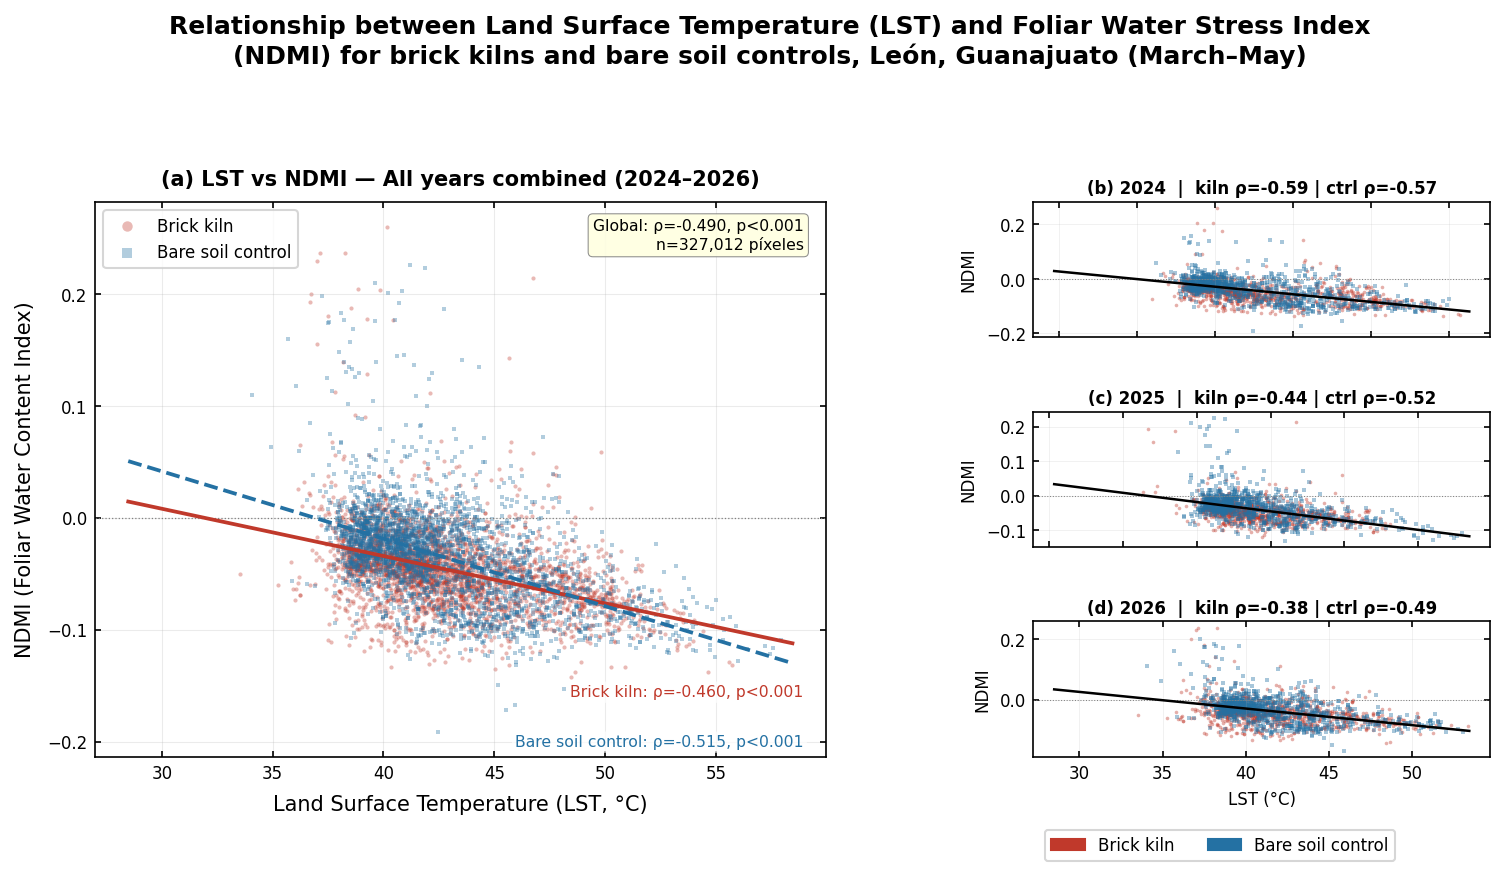


✅ Fig. 6 guardada en:
   /content/resultados_paper/Fig6_Scatter_LST_NDMI.png  (300 dpi)
   /content/resultados_paper/Fig6_Scatter_LST_NDMI.pdf  (vectorial, recomendado para Atmósfera)

──────────────────────────────────────────────────────────────────────────────
CAPTION SUGERIDO (copiar al paper, ajustar n final con datos reales):

Figure 6. Scatter plot of Land Surface Temperature (LST, °C) versus the
Normalized Difference Moisture Index (NDMI, equivalent to NDWI of Gao, 1996)
for all sampled pixels in brick kiln sites (red circles) and geographically
paired bare soil control sites (blue squares) across the three dry seasons
analyzed (March–May 2024–2026), León, Guanajuato, Mexico (n = XX pixels per
class). Panel (a) combines all years; panels (b)–(d) show each year
independently. Dashed and solid lines represent Ordinary Least Squares
regression fits per class (main panel) and combined regression per year
(inset panels). Spearman rank correlation coefficients (ρ) were computed on
t

In [ ]:
# ==============================================================================
# Scatter LST vs NDMI by class (Central hypothesis)
# Required files: pixel_data_2024/25/26.csv
# Target Journal: Atmósfera (UNAM) — 300 dpi, publication size
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

OUT_DIR = '/content/paper_results'
os.makedirs(OUT_DIR, exist_ok=True)

# ==============================================================================
# 1. LOAD AND CONCATENATE THE 3 YEARS
# ==============================================================================
df = pd.concat([
    pd.read_csv('/content/pixel_data_2024.csv'),
    pd.read_csv('/content/pixel_data_2025.csv'),
    pd.read_csv('/content/pixel_data_2026.csv'),
], ignore_index=True)

# Clean GEE columns
for col in ['.geo', 'system:index']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

df = df.dropna(subset=['LST_Celsius', 'NDMI', 'class', 'year'])
df['year'] = df['year'].astype(int)
df['class'] = df['class'].astype(str)

print(f"Total pixels for the figure: {len(df):,}")
print(f"Classes: {df['class'].unique()}")
print(f"Years: {sorted(df['year'].unique())}")

# ==============================================================================
# 2. CALCULATE SPEARMAN CORRELATIONS BY CLASS (for figure annotation)
# ==============================================================================
classes = ['kiln', 'bare_soil']
colors = {'kiln': '#c0392b', 'bare_soil': '#2471a3'}
labels = {'kiln': 'Brick kiln', 'bare_soil': 'Bare soil control'}
markers = {'kiln': 'o', 'bare_soil': 's'}

correlations = {}
for cls in classes:
    sub = df[df['class'] == cls]
    rho, p = stats.spearmanr(sub['LST_Celsius'], sub['NDMI'])
    correlations[cls] = {'rho': rho, 'p': p, 'n': len(sub)}
    sig = "p<0.001" if p < 0.001 else f"p={p:.3f}"
    print(f"{cls}: rho={rho:.3f}, {sig}, n={len(sub):,}")

# Global correlation
rho_global, p_global = stats.spearmanr(df['LST_Celsius'], df['NDMI'])
print(f"\nGlobal: rho={rho_global:.3f}, p={p_global:.2e}, n={len(df):,}")

# ==============================================================================
# 3. SAMPLING FOR VISUALIZATION
# ==============================================================================
# With >300k pixels the scatter is illegible. Using stratified sampling
# by class and year so each group is represented equally.
SAMPLE_SIZE = 3000  # per class — total ~6000 points, legible and fast

df_plot = pd.concat([
    df[df['class'] == cls].sample(
        min(SAMPLE_SIZE, len(df[df['class'] == cls])),
        random_state=42
    )
    for cls in classes
], ignore_index=True)

print(f"\nPixels in the figure (stratified sample): {len(df_plot):,}")
print("(Correlations were calculated on the full dataset)")

# ==============================================================================
# 4. FIGURE — Layout: main panel + 2 side panels by year
# ==============================================================================
# Structure:
#   Left panel (large): global scatter both classes 2024-2025-2026
#   Right panel (3 small): scatter separated by year

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

fig = plt.figure(figsize=(12, 5))

# Grid: 1 row, 2 sections — large panel (left) + 3 year panels (right)
gs = fig.add_gridspec(1, 2, width_ratios=[1.6, 1], wspace=0.35, top=0.85)
gs_right = gs[1].subgridspec(3, 1, hspace=0.55)

ax_main = fig.add_subplot(gs[0])
ax_2024 = fig.add_subplot(gs_right[0])
ax_2025 = fig.add_subplot(gs_right[1])
ax_2026 = fig.add_subplot(gs_right[2])
axes_year = {2024: ax_2024, 2025: ax_2025, 2026: ax_2026}

# ------------------------------------------------------------------
# MAIN PANEL — Global (3 years combined)
# ------------------------------------------------------------------
for cls in classes:
    sub = df_plot[df_plot['class'] == cls]
    ax_main.scatter(
        sub['LST_Celsius'], sub['NDMI'],
        c=colors[cls],
        marker=markers[cls],
        s=4, alpha=0.35, linewidths=0,
        label=labels[cls],
        rasterized=True
    )

# Regression lines by class (calculated on the FULL sample)
x_range = np.linspace(df['LST_Celsius'].min(), df['LST_Celsius'].max(), 200)
for cls in classes:
    sub_full = df[df['class'] == cls]
    slope, intercept, *_ = stats.linregress(sub_full['LST_Celsius'], sub_full['NDMI'])
    y_pred = slope * x_range + intercept
    ax_main.plot(x_range, y_pred,
                 color=colors[cls], linewidth=1.8,
                 linestyle='--' if cls == 'bare_soil' else '-',
                 zorder=5)

# Correlation annotations
y_annot = ax_main.get_ylim()[0] if ax_main.get_ylim()[0] != 0 else -0.3
annot_y = [0.08, 0.02]
for j, cls in enumerate(classes):
    c = correlations[cls]
    sig_str = "p<0.001" if c['p'] < 0.001 else f"p={c['p']:.3f}"
    ax_main.text(
        0.97, 0.13 - j * 0.09,
        f"{labels[cls]}: ρ={c['rho']:.3f}, {sig_str}",
        transform=ax_main.transAxes,
        ha='right', va='top', fontsize=7.5,
        color=colors[cls],
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none')
    )

# Global annotation
ax_main.text(
    0.97, 0.97,
    f"Global: ρ={rho_global:.3f}, p<0.001\nn={len(df):,} pixels",
    transform=ax_main.transAxes,
    ha='right', va='top', fontsize=7.5,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
              alpha=0.9, edgecolor='gray', linewidth=0.5)
)

ax_main.set_xlabel('Land Surface Temperature (LST, °C)', labelpad=6)
ax_main.set_ylabel('NDMI (Foliar Water Content Index)', labelpad=6)
ax_main.set_title('(a) LST vs NDMI — All years combined (2024–2026)', pad=8, fontweight='bold')
ax_main.legend(loc='upper left', framealpha=0.8, markerscale=2.5)
ax_main.axhline(0, color='gray', linewidth=0.6, linestyle=':')
ax_main.grid(True, alpha=0.25, linewidth=0.5)
sns_tick = dict(top=True, right=True, direction='in', length=3)
ax_main.tick_params(**sns_tick)

# ------------------------------------------------------------------
# PANELS BY YEAR (right column)
# ------------------------------------------------------------------
panel_letters = {2024: 'b', 2025: 'c', 2026: 'd'}

for year, ax in axes_year.items():
    df_y = df_plot[df_plot['year'] == year]
    df_y_full = df[df['year'] == year]

    for cls in classes:
        sub = df_y[df_y['class'] == cls]
        ax.scatter(
            sub['LST_Celsius'], sub['NDMI'],
            c=colors[cls], marker=markers[cls],
            s=3, alpha=0.4, linewidths=0,
            rasterized=True
        )

    # Global regression for the year (thin black line)
    sl, inter, *_ = stats.linregress(df_y_full['LST_Celsius'], df_y_full['NDMI'])
    x_a = np.linspace(df_y_full['LST_Celsius'].min(), df_y_full['LST_Celsius'].max(), 100)
    ax.plot(x_a, sl * x_a + inter, 'k-', linewidth=1.2, zorder=5)

    # rho for the year by class
    rho_k, _ = stats.spearmanr(
        df_y_full[df_y_full['class']=='kiln']['LST_Celsius'],
        df_y_full[df_y_full['class']=='kiln']['NDMI']
    )
    rho_c, _ = stats.spearmanr(
        df_y_full[df_y_full['class']=='bare_soil']['LST_Celsius'],
        df_y_full[df_y_full['class']=='bare_soil']['NDMI']
    )

    ax.set_title(f'({panel_letters[year]}) {year}  |  kiln ρ={rho_k:.2f} | ctrl ρ={rho_c:.2f}',
                 fontsize=8, pad=4, fontweight='bold')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax.grid(True, alpha=0.2, linewidth=0.4)
    ax.tick_params(**sns_tick)

    if year == 2026:
        ax.set_xlabel('LST (°C)', fontsize=8)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel('NDMI', fontsize=8)

# ------------------------------------------------------------------
# GLOBAL LEGEND
# ------------------------------------------------------------------
legend_patches = [
    mpatches.Patch(color=colors['kiln'], label='Brick kiln'),
    mpatches.Patch(color=colors['bare_soil'], label='Bare soil control'),
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=2,
    fontsize=8,
    framealpha=0.8,
    bbox_to_anchor=(0.75, -0.04)
)

# ------------------------------------------------------------------
# GLOBAL TITLE
# ------------------------------------------------------------------
fig.suptitle(
    'Relationship between Land Surface Temperature (LST) and Foliar Water Stress Index\n'
    '(NDMI) for brick kilns and bare soil controls, León, Guanajuato (March–May)',
    fontsize=12, y=1.1, ha='center', fontweight='bold'
)

plt.savefig(f'{OUT_DIR}/Scatter_LST_NDMI.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUT_DIR}/Scatter_LST_NDMI.pdf', bbox_inches='tight', facecolor='white')

plt.show()

print("\nPlot saved successfully:")
print(f"   {OUT_DIR}/Scatter_LST_NDMI.png  (300 dpi)")
print(f"   {OUT_DIR}/Scatter_LST_NDMI.pdf  (vector)")

# ==============================================================================
# SUGGESTED CAPTION
# ==============================================================================
print("""
------------------------------------------------------------------------------
SUGGESTED CAPTION (copy to the manuscript, adjust 'n' with actual data):

Scatter plot of Land Surface Temperature (LST, °C) versus the Normalized
Difference Moisture Index (NDMI, equivalent to NDWI of Gao, 1996) for all
sampled pixels in brick kiln sites (red circles) and geographically paired bare
soil control sites (blue squares) across the three dry seasons analyzed
(March–May 2024–2026), León, Guanajuato, Mexico (n = XX pixels per class).
Panel (a) combines all years; panels (b)–(d) show each year independently.
Dashed and solid lines represent Ordinary Least Squares regression fits per class
(main panel) and combined regression per year (inset panels). Spearman rank
correlation coefficients (ρ) were computed on the full dataset prior to
subsampling for visualization. Negative NDMI values indicate foliar water
deficit; the negative LST–NDMI relationship (ρ = –0.49, p < 0.001) supports
the hypothesis of thermally driven vegetation water stress in peri-urban areas
around brick kilns and bare soil surfaces.
------------------------------------------------------------------------------
""")

## Figura 7 pendiente traducir

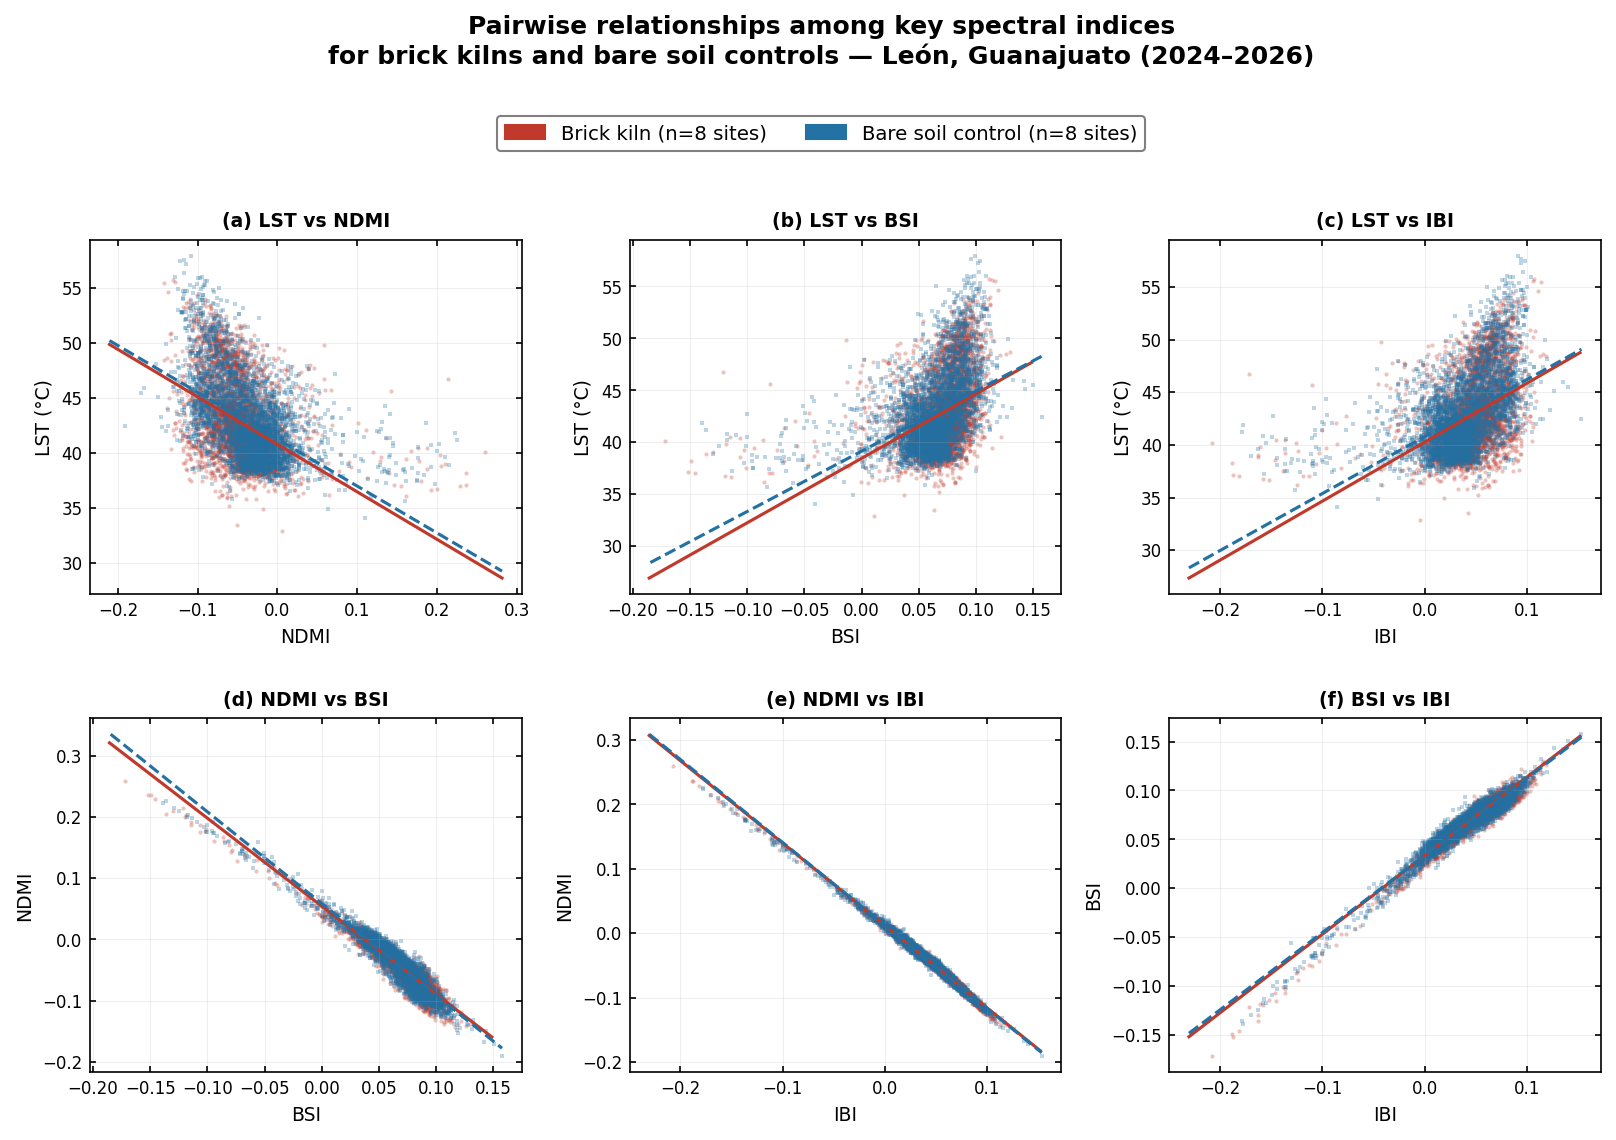


✅ Fig. 7 (Versión Horizontal 2x3) guardada:
   /content/resultados_paper/Fig7_Scatter_2x3_Horizontal.png  (300 dpi)
   /content/resultados_paper/Fig7_Scatter_2x3_Horizontal.pdf  (vectorial)


In [ ]:
# ==============================================================================
# Scatter 2x3: Bivariate relationships (LST, NDMI, BSI, IBI)
# Required files: pixel_data_2024/25/26.csv
# Target Journal: Atmósfera (UNAM) — 300 dpi, horizontal layout
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

OUT_DIR = '/content/paper_results'
os.makedirs(OUT_DIR, exist_ok=True)

# ==============================================================================
# 1. LOAD AND PREPARE DATA
# ==============================================================================
df = pd.concat([
    pd.read_csv('/content/pixel_data_2024.csv'),
    pd.read_csv('/content/pixel_data_2025.csv'),
    pd.read_csv('/content/pixel_data_2026.csv'),
], ignore_index=True)

for col in ['.geo', 'system:index']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Rename the original NDSI column to BSI to prevent errors
# in case the CSV maintains the previous name.
df.rename(columns={'NDSI': 'BSI'}, inplace=True)

VARS_FIG  = ['LST_Celsius', 'NDMI', 'BSI', 'IBI']
LABELS = {
    'LST_Celsius': 'LST (°C)',
    'NDMI':        'NDMI',
    'BSI':         'BSI',
    'IBI':         'IBI',
}

df = df.dropna(subset=VARS_FIG + ['class', 'year'])
df['class'] = df['class'].astype(str)
df['year']  = df['year'].astype(int)

# ==============================================================================
# 2. STRATIFIED SAMPLE (for visualization)
# ==============================================================================
N_PER_CLASS = 4000
CLASSES   = ['kiln', 'bare_soil']
COLORS  = {'kiln': '#c0392b', 'bare_soil': '#2471a3'}
CLASS_LABELS = {'kiln': 'Brick kiln', 'bare_soil': 'Bare soil control'}
MARKERS = {'kiln': 'o', 'bare_soil': 's'}

df_plot = pd.concat([
    df[df['class'] == c].sample(min(N_PER_CLASS, (df['class'] == c).sum()), random_state=42)
    for c in CLASSES
], ignore_index=True)

# ==============================================================================
# 3. DEFINE THE 6 VARIABLE PAIRS FOR THE 2x3 GRID
# ==============================================================================
# Defining exactly what goes on the X and Y axes for the 6 panels
plot_pairs = [
    ('NDMI', 'LST_Celsius', '(a) LST vs NDMI'),
    ('BSI',  'LST_Celsius', '(b) LST vs BSI'),
    ('IBI',  'LST_Celsius', '(c) LST vs IBI'),
    ('BSI',  'NDMI',        '(d) NDMI vs BSI'),
    ('IBI',  'NDMI',        '(e) NDMI vs IBI'),
    ('IBI',  'BSI',         '(f) BSI vs IBI')
]

# ==============================================================================
# 4. BUILD THE FIGURE (2x3 Horizontal Grid)
# ==============================================================================
plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    'font.size':      9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi':     150,
    'savefig.dpi':    300,
})

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
fig.subplots_adjust(hspace=0.35, wspace=0.25, top=0.85)
axes = axes.flatten()

for idx, (v_x, v_y, title) in enumerate(plot_pairs):
    ax = axes[idx]

    for cls in CLASSES:
        # Scatter on the subsample
        sub = df_plot[df_plot['class'] == cls][[v_x, v_y]].dropna()
        ax.scatter(
            sub[v_x], sub[v_y],
            c=COLORS[cls], marker=MARKERS[cls],
            s=4, alpha=0.3, linewidths=0, rasterized=True
        )

        # Regression on the full sample
        sub_full = df[df['class'] == cls][[v_x, v_y]].dropna()
        sl, inter, *_ = stats.linregress(sub_full[v_x], sub_full[v_y])
        x_rng = np.linspace(sub_full[v_x].min(), sub_full[v_x].max(), 100)
        ls = '-' if cls == 'kiln' else '--'
        ax.plot(x_rng, sl * x_rng + inter, color=COLORS[cls], linewidth=1.5, linestyle=ls, zorder=5)

    # Panel formatting
    ax.set_title(title, fontweight='bold', pad=6)
    ax.set_xlabel(LABELS[v_x])
    ax.set_ylabel(LABELS[v_y])
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.tick_params(direction='in', length=3, top=True, right=True)

# ==============================================================================
# 5. LEGEND AND GLOBAL TITLE
# ==============================================================================
legend_handles = [
    mpatches.Patch(color=COLORS['kiln'],    label='Brick kiln (n=8 sites)'),
    mpatches.Patch(color=COLORS['bare_soil'], label='Bare soil control (n=8 sites)'),
]

# Centered legend at the top
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.92),
    ncol=2,
    fontsize=9.5,
    framealpha=1,
    edgecolor='gray'
)

fig.suptitle(
    'Pairwise relationships among key spectral indices\n'
    'for brick kilns and bare soil controls — León, Guanajuato (2024–2026)',
    fontsize=12, fontweight='bold', y=1.05
)

# ==============================================================================
# 6. EXPORT
# ==============================================================================
plt.savefig(
    f'{OUT_DIR}/Scatter_2x3_Horizontal.png',
    dpi=300, bbox_inches='tight', facecolor='white'
)
plt.savefig(
    f'{OUT_DIR}/Scatter_2x3_Horizontal.pdf',
    bbox_inches='tight', facecolor='white'
)
plt.show()

print("\nPlot saved successfully (2x3 Horizontal Version):")
print(f"   {OUT_DIR}/Scatter_2x3_Horizontal.png  (300 dpi)")
print(f"   {OUT_DIR}/Scatter_2x3_Horizontal.pdf  (vector)")

## Year-on-year trend (2024–2026) - Temporary baseline

Cargando archivos CSV de píxeles...
Datos listos. Píxeles en buffer 500m: 76665

 ESTADÍSTICAS DE TENDENCIA INTERANUAL A 500m (Media ± Desv. Std.)

--- Variable: LST (°C) ---
                     Media  Desv_Std  N_Píxeles
anio clase                                     
2024 ladrillera     43.031     4.427      11969
     suelo_desnudo  42.904     4.354      13586
2025 ladrillera     44.103     3.195      11969
     suelo_desnudo  44.240     3.543      13586
2026 ladrillera     41.861     3.396      11969
     suelo_desnudo  41.972     3.370      13586

--- Variable: NDMI (Water Stress) ---
                    Media  Desv_Std  N_Píxeles
anio clase                                    
2024 ladrillera    -0.051     0.036      11969
     suelo_desnudo -0.042     0.044      13586
2025 ladrillera    -0.046     0.028      11969
     suelo_desnudo -0.038     0.039      13586
2026 ladrillera    -0.044     0.034      11969
     suelo_desnudo -0.037     0.041      13586

--- Variable: BSI (Bare S

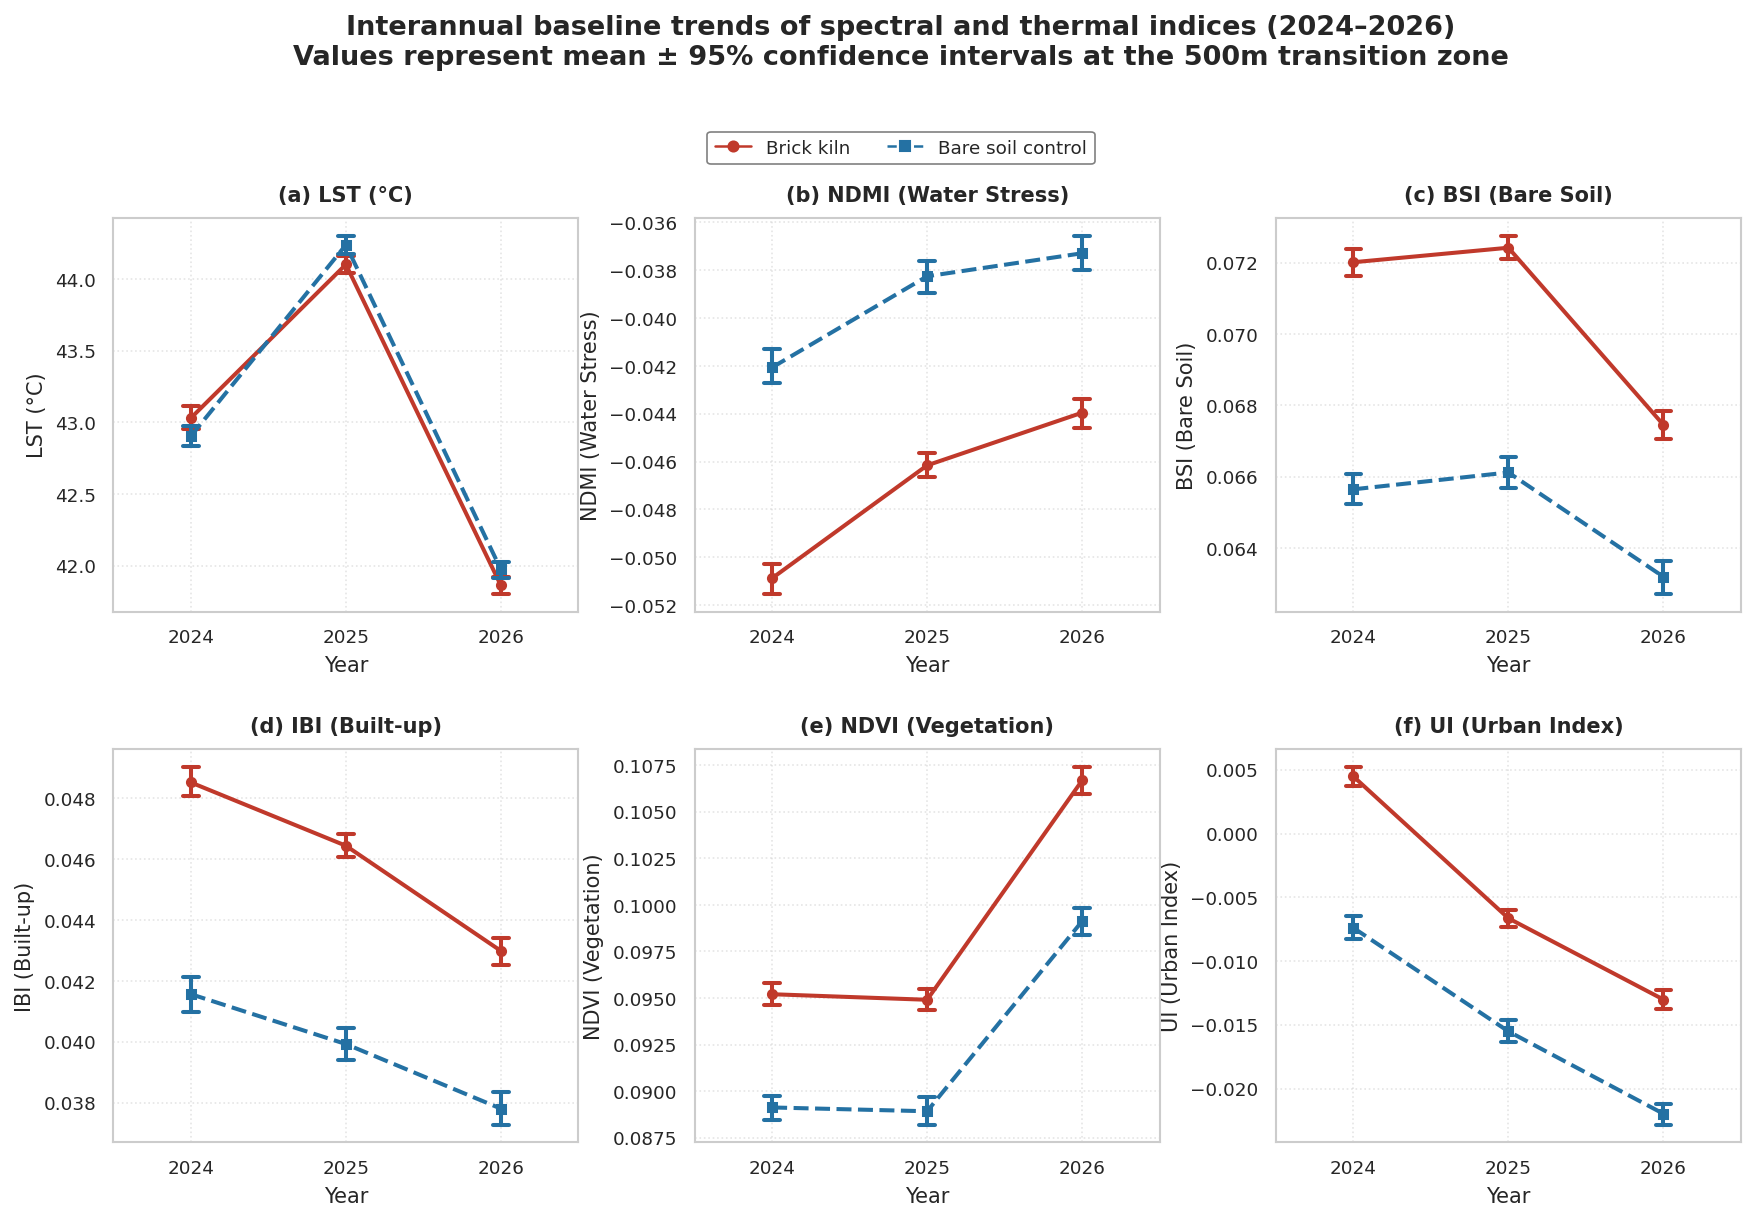

✅ Fig. 8 guardada (Tendencia Interanual 2024-2026)
   /content/resultados_paper/Fig8_Tendencia_Interanual.png  (300 dpi)
   /content/resultados_paper/Fig8_Tendencia_Interanual.pdf  (vectorial)


In [ ]:
# ==============================================================================
# Interannual trend (2024–2026) - Temporal baseline
# Required files: pixel_data_2024.csv, pixel_data_2025.csv, pixel_data_2026.csv
# Target Journal: Atmósfera (UNAM) — 300 dpi, 2x3 horizontal format
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

OUT_DIR = '/content/paper_results'
os.makedirs(OUT_DIR, exist_ok=True)

# ==============================================================================
# 1. LOAD AND CLEAN DATA (NEW SESSION)
# ==============================================================================
print("Loading pixel CSV files...")
years = [2024, 2025, 2026]
dfs = []
for year in years:
    path = f'/content/pixel_data_{year}.csv'
    if os.path.exists(path):
        dfs.append(pd.read_csv(path))
    else:
        print(f"Warning: File {path} not found")

# Concatenate all years
df_pixels = pd.concat(dfs, ignore_index=True)

# Clean unnecessary GEE columns
for col in ['.geo', 'system:index']:
    if col in df_pixels.columns:
        df_pixels.drop(columns=[col], inplace=True)

df_pixels['class'] = df_pixels['class'].astype(str)
df_pixels['year']  = df_pixels['year'].astype(int)

# ==============================================================================
# 2. PREPARE DATA FOR TREND
# ==============================================================================
# Filter only the variables to plot to save memory
VARS_PLOT = ['LST_Celsius', 'NDMI', 'NDSI', 'IBI', 'NDVI', 'UI']

# KEY FILTER: Using the 500m buffer as a representative transition zone
df_trend = df_pixels[df_pixels['buffer_m'] == 500]

print(f"Data ready. Pixels in 500m buffer: {len(df_trend)}")

# ==============================================================================
# 3. PRINT RESULTS TO CONSOLE
# ==============================================================================
LABELS = {
    'LST_Celsius': 'LST (°C)',
    'NDMI':        'NDMI (Water Stress)',
    'NDSI':        'BSI (Bare Soil)',
    'IBI':         'IBI (Built-up)',
    'NDVI':        'NDVI (Vegetation)',
    'UI':          'UI (Urban Index)'
}

print("\n================================================================================")
print(" INTERANNUAL TREND STATISTICS AT 500m (Mean ± Std. Dev.)")
print("================================================================================")

for var in VARS_PLOT:
    print(f"\n--- Variable: {LABELS[var]} ---")
    # Group by year and class, calculating mean, standard deviation, and count
    stats_df = df_trend.groupby(['year', 'class'])[var].agg(['mean', 'std', 'count']).dropna()
    stats_df.columns = ['Mean', 'Std_Dev', 'N_Pixels']
    print(stats_df.round(3).to_string())

print("================================================================================\n")

# ==============================================================================
# 4. CONFIGURATION AND FIGURE CREATION
# ==============================================================================
CLASSES  = ['kiln', 'bare_soil']
COLORS = {'kiln': '#c0392b', 'bare_soil': '#2471a3'}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.subplots_adjust(hspace=0.35, wspace=0.25, top=0.88)
axes = axes.flatten()
letters = ['a', 'b', 'c', 'd', 'e', 'f']

print("Generating line plots (Pointplots) with confidence intervals...")
for idx, var in enumerate(VARS_PLOT):
    ax = axes[idx]

    # Pointplot: Calculates mean and error bars (95% CI) automatically
    sns.pointplot(
        data=df_trend, x='year', y=var, hue='class',
        palette=COLORS, ax=ax, markers=['o', 's'],
        linestyles=['-', '--'], capsize=.1, errorbar=('ci', 95),
        scale=0.9
    )

    # Aesthetics for each panel
    ax.set_title(f'({letters[idx]}) {LABELS[var]}', fontweight='bold', pad=8)
    ax.set_xlabel('Year')
    ax.set_ylabel(LABELS[var])
    ax.grid(True, linestyle=':', alpha=0.5)

    # Ensure X axis shows full integers without decimals
    ax.set_xticks(range(len(years)))
    ax.set_xticklabels(years)

    # Remove individual seaborn legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# ==============================================================================
# 5. GLOBAL LEGEND AND TITLE
# ==============================================================================
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Create legend matching previous figures
line_kiln = mlines.Line2D([], [], color=COLORS['kiln'], marker='o', linestyle='-', label='Brick kiln')
line_ctrl = mlines.Line2D([], [], color=COLORS['bare_soil'], marker='s', linestyle='--', label='Bare soil control')

fig.legend(handles=[line_kiln, line_ctrl], loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=2, framealpha=1, edgecolor='gray')

fig.suptitle(
    'Interannual baseline trends of spectral and thermal indices (2024–2026)\n'
    'Values represent mean ± 95% confidence intervals at the 500m transition zone',
    fontsize=13, fontweight='bold', y=1.05
)

# ==============================================================================
# 6. SAVE RESULTS
# ==============================================================================
plt.savefig(f'{OUT_DIR}/Interannual_Trend.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUT_DIR}/Interannual_Trend.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("================================================================================")
print("Plot saved successfully (Interannual Trend 2024-2026)")
print(f"   {OUT_DIR}/Interannual_Trend.png  (300 dpi)")
print(f"   {OUT_DIR}/Interannual_Trend.pdf  (vector)")

## Violin plots LST by year × class

Cargando archivos CSV de píxeles...
Datos listos. Píxeles totales para la distribución: 327,012

 ESTADÍSTICAS DE DISTRIBUCIÓN LST (°C) POR AÑO Y CLASE
                    N_píxeles  Media  Desv_Std  Mínimo  Q1 (25%)  Mediana (50%)  Q3 (75%)  Máximo
anio clase                                                                                       
2024 ladrillera       52009.0  42.79      4.14   29.67     39.59          41.41     45.21   56.32
     suelo_desnudo    56995.0  42.62      4.06   33.01     39.40          41.21     45.04   56.01
2025 ladrillera       52009.0  43.94      3.03   30.34     41.67          43.22     45.73   54.30
     suelo_desnudo    56995.0  44.00      3.25   35.31     41.57          43.22     45.63   58.46
2026 ladrillera       52009.0  41.64      3.22   28.48     39.18          40.88     43.66   53.44
     suelo_desnudo    56995.0  41.74      3.12   33.99     39.44          40.95     43.39   53.05
Generando gráfico de violín...


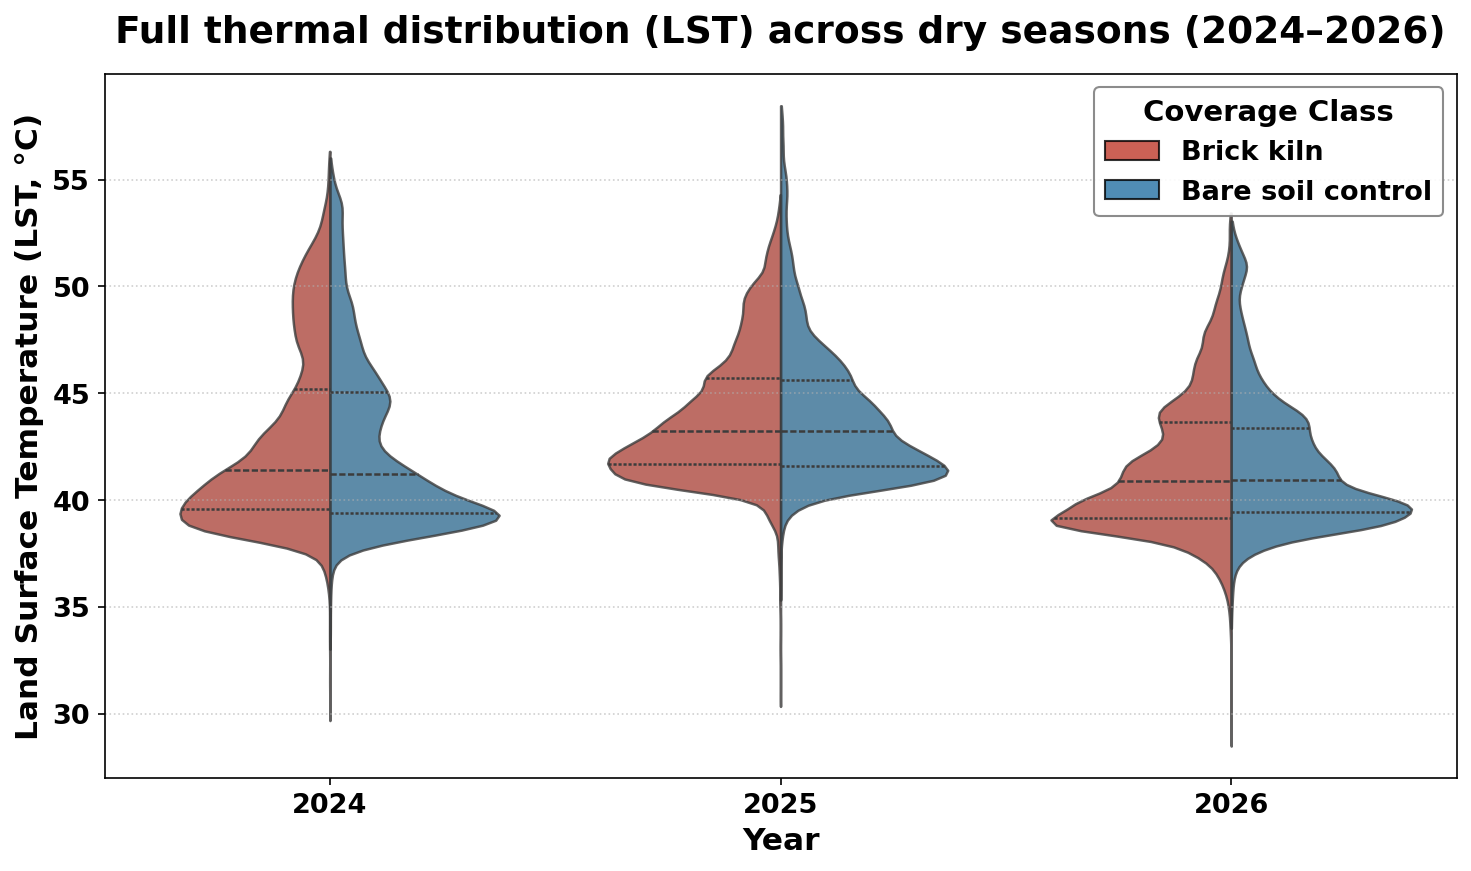

✅ Fig. 9 guardada (Violin Plots LST)
   /content/resultados_paper/Fig9_Violin_LST_Distribucion.png  (300 dpi)
   /content/resultados_paper/Fig9_Violin_LST_Distribucion.pdf  (vectorial)


In [ ]:
# ==============================================================================
# Violin plots LST by year × class (Full thermal distribution)
# Required files: pixel_data_2024.csv, pixel_data_2025.csv, pixel_data_2026.csv
# Target Journal: Atmósfera (UNAM) — 300 dpi
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

OUT_DIR = '/content/paper_results'
os.makedirs(OUT_DIR, exist_ok=True)


# ==============================================================================
# 1. DATA LOADING AND CLEANING
# ==============================================================================

print("Loading pixel CSV files...")

years = [2024, 2025, 2026]
dfs = []

for year in years:
    path = f'/content/pixel_data_{year}.csv'
    if os.path.exists(path):
        dfs.append(pd.read_csv(path))
    else:
        print(f"Warning: File {path} not found")

df_pixels = pd.concat(dfs, ignore_index=True)

for col in ['.geo', 'system:index']:
    if col in df_pixels.columns:
        df_pixels.drop(columns=[col], inplace=True)

# Rename Spanish columns to English if present
df_pixels.rename(columns={'clase': 'class', 'anio': 'year'}, inplace=True, errors='ignore')

df_pixels['class'] = df_pixels['class'].astype(str)
df_pixels['year'] = df_pixels['year'].astype(int)

df_violin = df_pixels.dropna(subset=['LST_Celsius'])

print(f"Data ready. Total pixels for distribution: {len(df_violin):,}")


# ==============================================================================
# 2. DESCRIPTIVE STATISTICS
# ==============================================================================

print("\n================================================================================")
print(" LST (°C) DISTRIBUTION STATISTICS BY YEAR AND CLASS")
print("================================================================================")

stats_lst = (
    df_violin
    .groupby(['year', 'class'])['LST_Celsius']
    .describe(percentiles=[.25, .50, .75])
)

stats_lst = stats_lst[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
]

stats_lst.columns = [
    'N_pixels',
    'Mean',
    'Std_Dev',
    'Min',
    'Q1 (25%)',
    'Median (50%)',
    'Q3 (75%)',
    'Max'
]

print(stats_lst.round(2).to_string())


# ==============================================================================
# 3. FONT CONFIGURATION
# ==============================================================================

# Adjust sizes here
FONT_TITLE = 18
FONT_AXES = 15
FONT_TICKS = 13
FONT_LEGEND = 13
FONT_LEGEND_TITLE = 14
FONT_SYMBOLOGY = 13


plt.rcParams.update({
    'font.family': 'DejaVu Sans',

    # Base size
    'font.size': FONT_TICKS,

    # Axes
    'axes.labelsize': FONT_AXES,
    'axes.titlesize': FONT_TITLE,

    # Ticks
    'xtick.labelsize': FONT_TICKS,
    'ytick.labelsize': FONT_TICKS,

    # Legend
    'legend.fontsize': FONT_LEGEND,
    'legend.title_fontsize': FONT_LEGEND_TITLE,

    'figure.dpi': 150,
    'savefig.dpi': 300,
})


# ==============================================================================
# 4. PLOT CREATION
# ==============================================================================

COLORS = {
    'kiln': '#c0392b',
    'bare_soil': '#2471a3'
}


fig, ax = plt.subplots(figsize=(10, 6))


print("Generating violin plot...")


sns.violinplot(
    data=df_violin,
    x='year',
    y='LST_Celsius',
    hue='class',
    split=True,
    inner='quartile',
    palette=COLORS,
    linewidth=1.2,
    cut=0,
    alpha=0.8,
    ax=ax
)


# ==============================================================================
# 5. FIGURE STYLING
# ==============================================================================

ax.set_title(
    'Full thermal distribution (LST) across dry seasons (2024–2026)',
    fontsize=FONT_TITLE,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Year',
    fontsize=FONT_AXES,
    fontweight='bold'
)

ax.set_ylabel(
    'Land Surface Temperature (LST, °C)',
    fontsize=FONT_AXES,
    fontweight='bold'
)


# Bold ticks
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')


ax.grid(
    True,
    linestyle=':',
    alpha=0.6,
    axis='y'
)


ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)


# ==============================================================================
# 6. CUSTOM LEGEND
# ==============================================================================

legend_handles = [
    mpatches.Patch(
        facecolor=COLORS['kiln'],
        edgecolor='black',
        label='Brick kiln',
        alpha=0.8
    ),

    mpatches.Patch(
        facecolor=COLORS['bare_soil'],
        edgecolor='black',
        label='Bare soil control',
        alpha=0.8
    )
]


legend = ax.legend(
    handles=legend_handles,
    title="Coverage Class",
    loc='upper right',
    framealpha=0.9,
    edgecolor='gray'
)

legend.get_title().set_fontweight('bold')

for text in legend.get_texts():
    text.set_fontweight('bold')


# ==============================================================================
# 7. EXPORT
# ==============================================================================

plt.tight_layout()


plt.savefig(
    f'{OUT_DIR}/Violin_LST_Distribution.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)


plt.savefig(
    f'{OUT_DIR}/Violin_LST_Distribution.pdf',
    bbox_inches='tight',
    facecolor='white'
)


plt.show()


print("================================================================================")
print("Plot saved successfully (LST Violin Plots)")
print(f"   {OUT_DIR}/Violin_LST_Distribution.png  (300 dpi)")
print(f"   {OUT_DIR}/Violin_LST_Distribution.pdf  (vector)")

## LST spatial distribution map


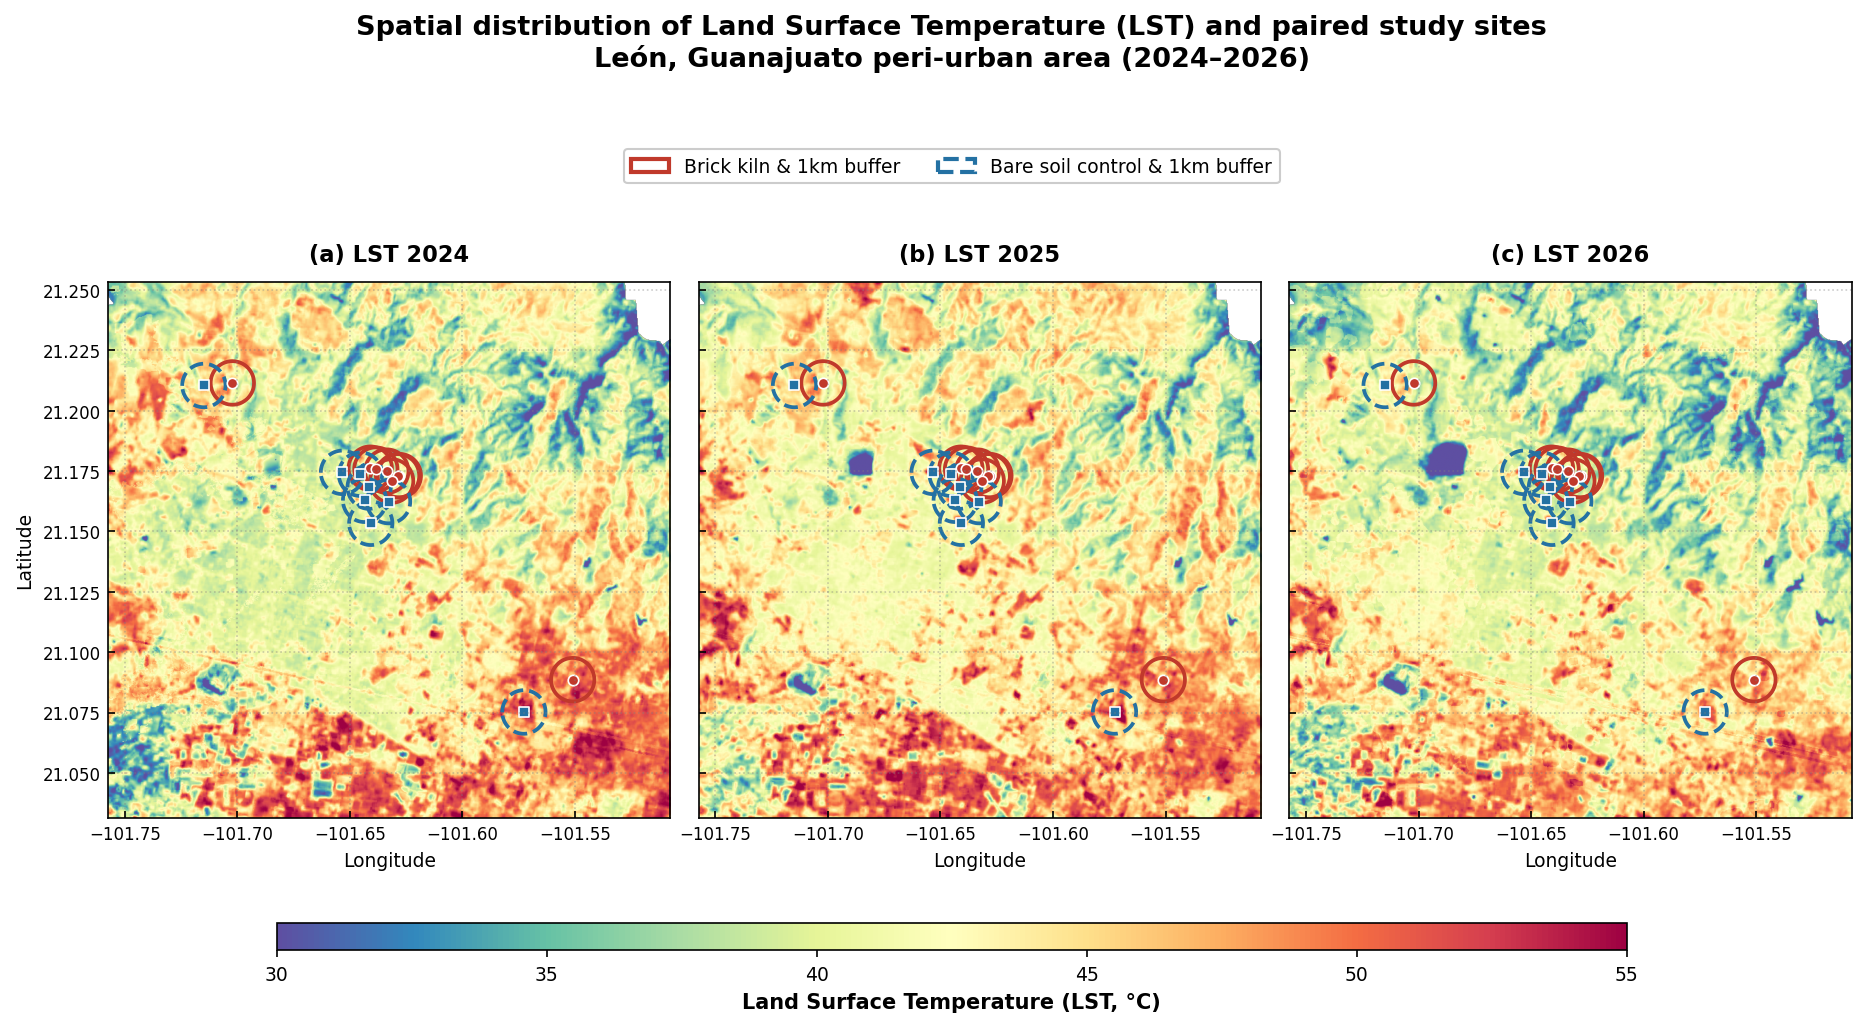


✅ Fig. 10 (Mapas LST) guardada:
   /content/resultados_paper/Fig10_Mapas_LST.png  (300 dpi)
   /content/resultados_paper/Fig10_Mapas_LST.pdf  (vectorial)


In [ ]:
# ==============================================================================
# Fig. 10 — LST spatial distribution map (2024-2026) with paired design
# Target Journal: Atmósfera (UNAM) — 300 dpi, 1x3 horizontal layout
# ==============================================================================
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

OUT_DIR = '/content/paper_results'
os.makedirs(OUT_DIR, exist_ok=True)

# ==============================================================================
# 1. LOAD VECTORS (Polygons from GEE exported GeoJSON)
# ==============================================================================
gdf = gpd.read_file('/content/Poligonos_Estudio.geojson')

# Separate classes (assuming the GeoJSON retains original Spanish class names)
kilns = gdf[gdf['clase'] == 'ladrillera']
controls = gdf[gdf['clase'] == 'suelo_desnudo']

# Extract centroids
cent_kiln = kilns.geometry.centroid
cent_ctrl = controls.geometry.centroid

# Create 1000m Buffers (Projecting to UTM Zone 14N EPSG:32614 and back to WGS84)
buff_kiln = kilns.to_crs(epsg=32614).geometry.centroid.buffer(1000).to_crs(epsg=4326)
buff_ctrl = controls.to_crs(epsg=32614).geometry.centroid.buffer(1000).to_crs(epsg=4326)

# Expanded Bounding Box from polygons to focus the map
minx, miny, maxx, maxy = gdf.total_bounds
margin = 0.04 # Margin in decimal degrees
bbox_minx, bbox_miny, bbox_maxx, bbox_maxy = minx - margin, miny - margin, maxx + margin, maxy + margin

# ==============================================================================
# 2. MAP CONFIGURATION AND TEMPERATURE RANGES
# ==============================================================================
years = [2024, 2025, 2026]
tiff_files = [f'/content/LST_Leon_{year}.tif' for year in years]

# Global color scale
VMIN = 30.0
VMAX = 55.0
cmap = plt.cm.get_cmap('Spectral_r')
norm = Normalize(vmin=VMIN, vmax=VMAX)

# ==============================================================================
# 3. CREATE FIGURE
# ==============================================================================
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
# ADD bottom=0.20 TO LIFT MAPS AND LEAVE SPACE BELOW
fig.subplots_adjust(wspace=0.05, top=0.85, bottom=0.20)

for i, (year, ax, tiff_path) in enumerate(zip(years, axes, tiff_files)):

    # 3.1 Read raster using WINDOWED READING (RAM Optimization)
    with rasterio.open(tiff_path) as src:
        # Create a window matching our data bounding box
        window = from_bounds(bbox_minx, bbox_miny, bbox_maxx, bbox_maxy, src.transform)

        # Read ONLY the requested window
        raster_data = src.read(1, window=window)
        raster_data = np.ma.masked_where(raster_data < 0, raster_data)

        # Calculate the actual geographic extent of this cropped window
        win_transform = src.window_transform(window)
        win_bounds = rasterio.windows.bounds(window, src.transform)
        extent = [win_bounds[0], win_bounds[2], win_bounds[1], win_bounds[3]] # left, right, bottom, top

        im = ax.imshow(raster_data, cmap=cmap, norm=norm, extent=extent)

    # 3.2 Add Buffers (Visible rings)
    buff_kiln.plot(ax=ax, facecolor='none', edgecolor='#c0392b', linewidth=1.8, linestyle='-')
    buff_ctrl.plot(ax=ax, facecolor='none', edgecolor='#2471a3', linewidth=1.8, linestyle='--')

    # 3.3 Add Centroids (Points)
    cent_kiln.plot(ax=ax, color='#c0392b', marker='o', markersize=25, edgecolor='white', linewidth=0.8)
    cent_ctrl.plot(ax=ax, color='#2471a3', marker='s', markersize=25, edgecolor='white', linewidth=0.8)

    # 3.4 Panel styling
    letters = ['a', 'b', 'c']
    ax.set_title(f'({letters[i]}) LST {year}', fontweight='bold', pad=10)
    ax.tick_params(axis='both', labelsize=8, direction='in')
    if i == 0:
        ax.set_ylabel('Latitude', fontsize=9)
    ax.set_xlabel('Longitude', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.4, color='gray')

    # Ensure the final framing matches the window
    ax.set_xlim(bbox_minx, bbox_maxx)
    ax.set_ylim(bbox_miny, bbox_maxy)

# ==============================================================================
# 4. COLORBAR AND GLOBAL LEGEND
# ==============================================================================
# LOWER THE COLORBAR (second value '0.08' is the Y position)
cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Land Surface Temperature (LST, °C)', fontweight='bold', fontsize=10)
cbar.ax.tick_params(labelsize=9)

legend_elements = [
    mpatches.Patch(facecolor='none', edgecolor='#c0392b', linewidth=2, label='Brick kiln & 1km buffer'),
    mpatches.Patch(facecolor='none', edgecolor='#2471a3', linewidth=2, linestyle='--', label='Bare soil control & 1km buffer')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=2, framealpha=1)

fig.suptitle(
    'Spatial distribution of Land Surface Temperature (LST) and paired study sites\n'
    'León, Guanajuato peri-urban area (2024–2026)',
    fontsize=13, fontweight='bold', y=1.12
)

# Save
plt.savefig(f'{OUT_DIR}/Fig10_LST_Maps.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUT_DIR}/Fig10_LST_Maps.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("\nFig. 10 (LST Maps) saved:")
print(f"   {OUT_DIR}/Fig10_LST_Maps.png  (300 dpi)")
print(f"   {OUT_DIR}/Fig10_LST_Maps.pdf  (vector)")

## Spatial Comparison LST vs NDMI (2024-2026 Average)

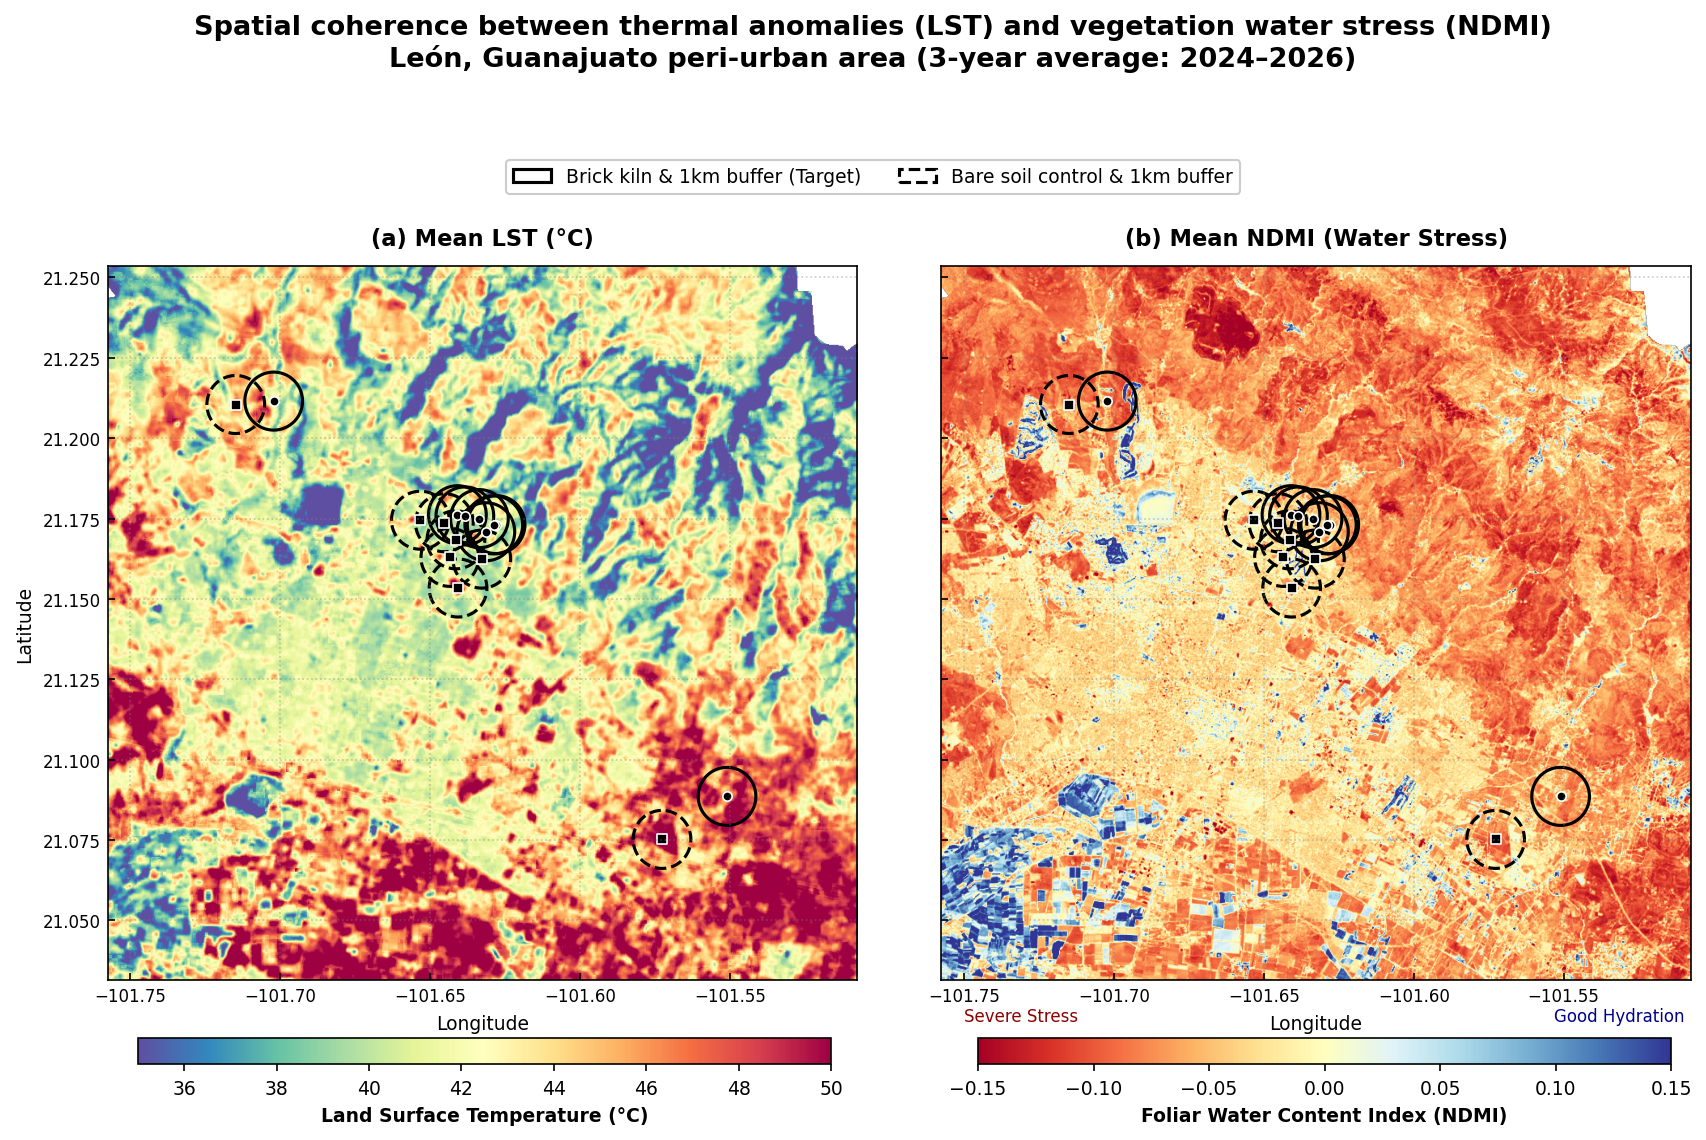


✅ Fig. 11 guardada (LST vs NDMI Mapas)


In [ ]:
# ==============================================================================
# Spatial Comparison LST vs NDMI (2024-2026 Average)
# Target Journal: Atmósfera (UNAM) — 300 dpi, 1x2 horizontal layout
# ==============================================================================
import rasterio
from rasterio.windows import from_bounds
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

OUT_DIR = '/content/paper_results'
os.makedirs(OUT_DIR, exist_ok=True)

# ==============================================================================
# 1. LOAD VECTORS
# ==============================================================================
gdf = gpd.read_file('/content/Poligonos_Estudio.geojson')

kilns = gdf[gdf['clase'] == 'ladrillera']
controls = gdf[gdf['clase'] == 'suelo_desnudo']

cent_kiln = kilns.geometry.centroid
cent_ctrl = controls.geometry.centroid

# 1000m Buffers for clear visualization
buff_kiln = kilns.to_crs(epsg=32614).geometry.centroid.buffer(1000).to_crs(epsg=4326)
buff_ctrl = controls.to_crs(epsg=32614).geometry.centroid.buffer(1000).to_crs(epsg=4326)

# Expanded Bounding Box
minx, miny, maxx, maxy = gdf.total_bounds
margin = 0.04
bbox_minx, bbox_miny, bbox_maxx, bbox_maxy = minx - margin, miny - margin, maxx + margin, maxy + margin

# ==============================================================================
# 2. MAP CONFIGURATION
# ==============================================================================
files = {
    'LST': '/content/LST_Promedio_24_26.tif',
    'NDMI': '/content/NDMI_Promedio_24_26.tif'
}

# Separate color palettes
cmap_lst = plt.cm.get_cmap('Spectral_r') # Blue to Red (Temperature)
cmap_ndmi = plt.cm.get_cmap('RdYlBu')    # Red (Dry/Stress) to Blue (Wet)

# Limits (adjust according to your data if the map is too saturated or pale)
norm_lst = Normalize(vmin=35.0, vmax=50.0)
norm_ndmi = Normalize(vmin=-0.15, vmax=0.15)

# ==============================================================================
# 3. CREATE 1x2 FIGURE
# ==============================================================================
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 9, 'figure.dpi': 150})

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
fig.subplots_adjust(wspace=0.05, top=0.88, bottom=0.2)

configs = [
    (axes[0], files['LST'], cmap_lst, norm_lst, '(a) Mean LST (°C)', 'Land Surface Temperature (°C)'),
    (axes[1], files['NDMI'], cmap_ndmi, norm_ndmi, '(b) Mean NDMI (Water Stress)', 'Foliar Water Content Index (NDMI)')
]

im_list = [] # Store images for colorbars

for ax, tiff_path, cmap, norm, title, label_cbar in configs:

    with rasterio.open(tiff_path) as src:
        window = from_bounds(bbox_minx, bbox_miny, bbox_maxx, bbox_maxy, src.transform)
        raster_data = src.read(1, window=window)

        # Mask for LST (ignore < 0) or NDMI (ignore typical GEE nulls < -1)
        if 'LST' in tiff_path:
            raster_data = np.ma.masked_where(raster_data < 0, raster_data)
        else:
            raster_data = np.ma.masked_where(raster_data < -1, raster_data)

        win_bounds = rasterio.windows.bounds(window, src.transform)
        extent = [win_bounds[0], win_bounds[2], win_bounds[1], win_bounds[3]]

        im = ax.imshow(raster_data, cmap=cmap, norm=norm, extent=extent)
        im_list.append((im, label_cbar))

    # Rings and Centroids
    buff_kiln.plot(ax=ax, facecolor='none', edgecolor='#000000', linewidth=1.5, linestyle='-')
    buff_ctrl.plot(ax=ax, facecolor='none', edgecolor='#000000', linewidth=1.5, linestyle='--')
    cent_kiln.plot(ax=ax, color='#000000', marker='o', markersize=20, edgecolor='white', linewidth=0.8)
    cent_ctrl.plot(ax=ax, color='#000000', marker='s', markersize=20, edgecolor='white', linewidth=0.8)

    # Text
    ax.set_title(title, fontweight='bold', pad=10)
    ax.tick_params(axis='both', labelsize=8, direction='in')
    ax.set_xlabel('Longitude')
    if ax == axes[0]:
        ax.set_ylabel('Latitude')
    ax.grid(True, linestyle=':', alpha=0.4, color='gray')
    ax.set_xlim(bbox_minx, bbox_maxx)
    ax.set_ylim(bbox_miny, bbox_maxy)

# ==============================================================================
# 4. COLORBARS AND LEGEND (One cbar below each panel)
# ==============================================================================
# Colorbar Panel A (LST)
cbar_ax1 = fig.add_axes([0.15, 0.12, 0.33, 0.025])
cbar1 = fig.colorbar(im_list[0][0], cax=cbar_ax1, orientation='horizontal')
cbar1.set_label(im_list[0][1], fontweight='bold')

# Colorbar Panel B (NDMI)
cbar_ax2 = fig.add_axes([0.55, 0.12, 0.33, 0.025])
cbar2 = fig.colorbar(im_list[1][0], cax=cbar_ax2, orientation='horizontal')
cbar2.set_label(im_list[1][1], fontweight='bold')
# Add notation for quick NDMI understanding
cbar2.ax.text(-0.02, 1.5, 'Severe Stress', transform=cbar2.ax.transAxes, ha='left', va='bottom', fontsize=8, color='darkred')
cbar2.ax.text(1.02, 1.5, 'Good Hydration', transform=cbar2.ax.transAxes, ha='right', va='bottom', fontsize=8, color='darkblue')

# Legend (using black to stand out against temperature or moisture colors)
legend_elements = [
    mpatches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, label='Brick kiln & 1km buffer (Target)'),
    mpatches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, linestyle='--', label='Bare soil control & 1km buffer')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=2, framealpha=1)

fig.suptitle(
    'Spatial coherence between thermal anomalies (LST) and vegetation water stress (NDMI)\n'
    'León, Guanajuato peri-urban area (3-year average: 2024–2026)',
    fontsize=13, fontweight='bold', y=1.12
)

plt.savefig(f'{OUT_DIR}/LST_vs_NDMI_Maps.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUT_DIR}/LST_vs_NDMI_Maps.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("\nPlot saved successfully (LST vs NDMI Maps)")